In [5]:
import uproot
print("uproot version: ", uproot.__version__)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import pickle
from collections import Counter
from particle import Particle

import awkward as ak

f = uproot.open('/Users/katherinepulido/Desktop/SURPRISE_Test_Samples_v10_04_07_05_Run4b_hyper_unified_reco2_BNB_nu_NC_pi0_overlay_may8_reco2_hist_62280465_snapshot.root')
fdirt = uproot.open('/Users/katherinepulido/Downloads/SURPRISE_Test_Samples_v10_04_07_05_Run4b_hyper_unified_reco2_BNB_dirt_may8_reco2_hist_62280564_snapshot.root')
fnu = uproot.open('/Users/katherinepulido/Downloads/SURPRISE_Test_Samples_v10_04_07_05_Run4b_super_unified_reco2_BNB_nu_overlay_reco2_hist.root')

uproot version:  5.6.2


## Load Variables

In [6]:

T_bdt_vars = ['cosmict_flag']           # variables involved with BDT training (if you want to train your own BDT, lots of these variables will be useful)
                            # many of these variables describe specific features of the WC spacepoints using this code: https://github.com/BNLIF/wire-cell-pid/blob/master/src/NeutrinoID_nue_tagger.h
#    'single_photon_ncpi0_score',                        # here, we just include higher level outputs:
##    "nue_score",                    # BDT score for nue selection, used for the WC inclusive nueCC analysis
 #   "numu_score",                   # BDT score for numu selection, used for the WC inclusive numuCC selections
 #   "nc_delta_score",               # BDT score for NC Delta selection
 #   "nc_pio_score",                 # BDT score for NC pi0 selection
 #   "numu_cc_flag",                 # flag, -1 means not generic selected, 0 means generic selected, 1 means cut-based numuCC selected. We often use "numu_cc_flag >= 0" to apply generic neutrino selection.
    
#]

T_eval_vars = [             # variables involved with low level reconstruction and truth information
    "run",                         # run number
    "subrun",                       # subrun number
    "event",                        # event number
    "match_isFC",                   # reconstructed cluster is fully contained (FC), boolean
    "truth_nuEnergy",               # true neutrino energy (MeV)
    "truth_nuPdg",                  # true neutrino pdg code
    "truth_isCC",                   # true interaction type is charged current, boolean
    "match_completeness_energy",    # the true energy deposited in the clusters that are 3D-matched with the reconstructed neutrino clusters (MeV)
    "truth_energyInside",           # the true energy deposited in the TPC Fiducial Volume (MeV)
    "truth_vtxInside",              # boolean, true neutrino vertex is inside the TPC Fiducial Volume
    "truth_vtxX",                   # true neutrino vertex x (cm)
    "truth_vtxY",                   # true neutrino vertex y (cm)
    "truth_vtxZ",                   # true neutrino vertex z (cm)
    "weight_cv",                    # GENIE MicroBooNE tune event weight (which should be corrected by also using weight_spline)
    "weight_spline",                # additional weight to correct the GENIE tune for certain events
    'flash_measPe',
    'flash_predPe',
]
T_eval_data_vars = [        # same as above, but for data files we do not attempt to load any truth information
    "run",
    "subrun",
    "event",
    "match_isFC",
]

T_kine_vars = [             # variables involved with kinematic reconstruction
    "kine_reco_Enu",                # reconstructed neutrino energy (MeV). "kine_reco_Enu > 0" is another way to apply generic neutrino selection.
    "kine_energy_particle",         # energy of each reco particle
    "kine_particle_type", # pdg code of each reco particle
    "kine_pio_mass",
    "kine_pio_energy_2",
    "kine_pio_flag"
]

T_pf_vars = [               # variables involved with individual particles
    "truth_NprimPio",
    "truth_NCDelta",
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",            # reconstructed muon momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showerMomentum",          # reconstructed primary shower momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",

    # truth shower = xyz ke

    'truth_corr_showervtxX', 
    'truth_corr_showervtxY', 
    'truth_corr_showervtxZ', 
    'truth_showerKE',

    # These variables are related to individual true particles
    "truth_Ntrack",
    "truth_id",
    "truth_pdg",
    "truth_mother",
    "truth_startMomentum",
    "truth_startXYZT",
    "truth_endXYZT",

    # These variables are related to individual reco particles
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    "Ph_Tot", 
    'PMT_Amp', # Amplitude of the PMT pulse if PE equivalent.
    'PMT_Time', # Time of the PMT pulse in ns.
    'RWM_Time', # time the RWM pulse arrived in ns. This serves as your “t0” and is always 0 for MC
    'PMT_Sat', # flag indicating if the given PMT was saturated (1) or not (0)
    'PMT_TimeDL', # Amount of time the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeDP', # Amount of time daughter particle that produced the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeProp', # Sum of the previous two variables.
    'PMT_ID' # ID of the PMT, useful for bookkeeping an needed to determine its location if you are going to recalculate and times.
]

T_pf_data_vars = [          # same as above, but for data files we do not attempt to load any truth information
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",
    "reco_showerMomentum",
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    'kine_reco_Enu'
]

blip_vars = [
    "nblips_saved",
    "blip_x",
    "blip_y",
    "blip_z",
    #"blip_size",
    "blip_energy",
    "blip_charge",
    "blip_nplanes",
    "blip_proxtrkdist",
    "blip_proxtrkid",
    "blip_touchtrk",
    "blip_touchtrkid",
    #"blip_badwirefrac",
    "blip_pl0_nwires",
    "blip_pl1_nwires",
    "blip_pl2_nwires",
    "blip_pl0_bydeadwire",
    "blip_pl1_bydeadwire",
    "blip_pl2_bydeadwire",
    #"blip_pl0_centerwire",
    #"blip_pl1_centerwire",
    #"blip_pl2_centerwire",
    "blip_true_g4id",
    "blip_true_pdg",
    "blip_true_energy",
]

CRT_vars = [
    'crtveto', # closest distance between shw start and space points to 
    'CosmicIP',
    '_closestNuCosmicDist',
    'crthitpe',
]

PMT_vars = [
    'flash_pe_flash_matching_v', # vector of photo electrons 
    'flash_pe_flash_matching', # sum of above vector
    'slice_pe_flash_matching_v', # vector of predicted photoelectrons ? 
    'flash_time_flash_matching', # 
    'flash_y_flash_matching',
    'flash_z_flash_matching',
    'flash_timewidth_flash_matching',
    'flash_ywidth_flash_matching',
    'flash_zwidth_flash_matching',
    'nu_flashmatch_score',
    'nu_centerX',
    'nu_centerY',
    'nu_centerZ',
    'best_cosmic_flashmatch_score',
]

spacepoints = [
    'Trecchargeblob_spacepoints_x',
    'Trecchargeblob_spacepoints_y',
    'Trecchargeblob_spacepoints_z',
    'Trecchargeblob_spacepoints_q'
]

vars = {}
vars.update(f["wcpselection"]["T_BDTvars"].arrays(T_bdt_vars, library="np"))
vars.update(f["wcpselection"]["T_eval"].arrays(T_eval_vars, library="np"))
vars.update(f["wcpselection"]["T_KINEvars"].arrays(T_kine_vars, library="np"))
vars.update(f["wcpselection"]["T_PFeval"].arrays(T_pf_vars, library="np"))
vars.update(f["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
vars.update(f["nuselection"]["NeutrinoSelectionFilter"].arrays(PMT_vars, library="np"))
vars.update(f["nuselection"]["NeutrinoSelectionFilter"].arrays(CRT_vars, library="np"))
vars.update(f["wcpselection"]["T_spacepoints"].arrays(spacepoints, library="np"))

vars.update(f["wcpselection"]["T_BDTvars"]['shw_sp_n_20mev_showers'].arrays(library="np"))
vars.update(f["wcpselection"]["T_BDTvars"]['shw_sp_20mev_showers'].arrays(library="np"))

file_POT = np.sum(f["wcpselection"]["T_pot"].arrays("pot_tor875good", library="np")["pot_tor875good"])
for col in vars:
    vars[col] = vars[col].tolist()
wc_df = pd.DataFrame(vars)

In [7]:
T_bdt_vars = []              # variables involved with BDT training (if you want to train your own BDT, lots of these variables will be useful)
                            # many of these variables describe specific features of the WC spacepoints using this code: https://github.com/BNLIF/wire-cell-pid/blob/master/src/NeutrinoID_nue_tagger.h
#    'single_photon_ncpi0_score',                        # here, we just include higher level outputs:
##    "nue_score",                    # BDT score for nue selection, used for the WC inclusive nueCC analysis
 #   "numu_score",                   # BDT score for numu selection, used for the WC inclusive numuCC selections
 #   "nc_delta_score",               # BDT score for NC Delta selection
 #   "nc_pio_score",                 # BDT score for NC pi0 selection
 #   "numu_cc_flag",                 # flag, -1 means not generic selected, 0 means generic selected, 1 means cut-based numuCC selected. We often use "numu_cc_flag >= 0" to apply generic neutrino selection.
#]

T_eval_vars = [             # variables involved with low level reconstruction and truth information
    "run",                         # run number
    "subrun",                       # subrun number
    "event",                        # event number
    "match_isFC",                   # reconstructed cluster is fully contained (FC), boolean
    "truth_nuEnergy",               # true neutrino energy (MeV)
    "truth_nuPdg",                  # true neutrino pdg code
    "truth_isCC",                   # true interaction type is charged current, boolean
    "match_completeness_energy",    # the true energy deposited in the clusters that are 3D-matched with the reconstructed neutrino clusters (MeV)
    "truth_energyInside",           # the true energy deposited in the TPC Fiducial Volume (MeV)
    "truth_vtxInside",              # boolean, true neutrino vertex is inside the TPC Fiducial Volume
    "truth_vtxX",                   # true neutrino vertex x (cm)
    "truth_vtxY",                   # true neutrino vertex y (cm)
    "truth_vtxZ",                   # true neutrino vertex z (cm)
    "weight_cv",                    # GENIE MicroBooNE tune event weight (which should be corrected by also using weight_spline)
    "weight_spline",                # additional weight to correct the GENIE tune for certain events
    'flash_measPe',
    'flash_predPe',    
]
T_eval_data_vars = [        # same as above, but for data files we do not attempt to load any truth information
    "run",
    "subrun",
    "event",
    "match_isFC",
]

T_kine_vars = [             # variables involved with kinematic reconstruction
    "kine_reco_Enu",                # reconstructed neutrino energy (MeV). "kine_reco_Enu > 0" is another way to apply generic neutrino selection.
    "kine_energy_particle",         # energy of each reco particle
    "kine_particle_type", # pdg code of each reco particle
    "kine_pio_mass",
    "kine_pio_energy_2",
    "kine_pio_flag"
]

T_pf_vars = [               # variables involved with individual particles
    "truth_NprimPio",
    "truth_NCDelta",
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",            # reconstructed muon momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showerMomentum",          # reconstructed primary shower momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",

    # truth shower = xyz ke

    'truth_corr_showervtxX', 
    'truth_corr_showervtxY', 
    'truth_corr_showervtxZ', 
    'truth_showerKE',

    # These variables are related to individual true particles
    "truth_Ntrack",
    "truth_id",
    "truth_pdg",
    "truth_mother",
    "truth_startMomentum",
    "truth_startXYZT",
    "truth_endXYZT",

    # These variables are related to individual reco particles
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    "Ph_Tot", 
    'PMT_Amp', # Amplitude of the PMT pulse if PE equivalent.
    'PMT_Time', # Time of the PMT pulse in ns.
    'RWM_Time', # time the RWM pulse arrived in ns. This serves as your “t0” and is always 0 for MC
    'PMT_Sat', # flag indicating if the given PMT was saturated (1) or not (0)
    'PMT_TimeDL', # Amount of time the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeDP', # Amount of time daughter particle that produced the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeProp', # Sum of the previous two variables.
    'PMT_ID' # ID of the PMT, useful for bookkeeping an needed to determine its location if you are going to recalculate and times.
]

T_pf_data_vars = [          # same as above, but for data files we do not attempt to load any truth information
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",
    "reco_showerMomentum",
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    'kine_reco_Enu'
]

blip_vars = [
    "nblips_saved",
    "blip_x",
    "blip_y",
    "blip_z",
    #"blip_size",
    "blip_energy",
    "blip_charge",
    "blip_nplanes",
    "blip_proxtrkdist",
    "blip_proxtrkid",
    "blip_touchtrk",
    "blip_touchtrkid",
    #"blip_badwirefrac",
    "blip_pl0_nwires",
    "blip_pl1_nwires",
    "blip_pl2_nwires",
    "blip_pl0_bydeadwire",
    "blip_pl1_bydeadwire",
    "blip_pl2_bydeadwire",
    #"blip_pl0_centerwire",
    #"blip_pl1_centerwire",
    #"blip_pl2_centerwire",
    "blip_true_g4id",
    "blip_true_pdg",
    "blip_true_energy",
]

# CRT and light variables

CRT_vars = [
    'crtveto', # closest distance between shw start and space points to 
    'CosmicIP',
    '_closestNuCosmicDist',
    'crthitpe',
]

PMT_vars = [
    'flash_pe_flash_matching_v', # vector of photo electrons 
    'flash_pe_flash_matching', # sum of above vector
    'slice_pe_flash_matching_v', # vector of predicted photoelectrons ? 
    'flash_time_flash_matching', # 
    'flash_y_flash_matching',
    'flash_z_flash_matching',
    'flash_timewidth_flash_matching',
    'flash_ywidth_flash_matching',
    'flash_zwidth_flash_matching',
    'nu_flashmatch_score',
    'nu_centerX',
    'nu_centerY',
    'nu_centerZ',
    'best_cosmic_flashmatch_score',
]

spacepoints = [
    'Trecchargeblob_spacepoints_x',
    'Trecchargeblob_spacepoints_y',
    'Trecchargeblob_spacepoints_z',
    'Trecchargeblob_spacepoints_q'
]

vars = {}
vars.update(fdirt["nuselection"]["NeutrinoSelectionFilter"].arrays(PMT_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_BDTvars"].arrays(T_bdt_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_eval"].arrays(T_eval_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_KINEvars"].arrays(T_kine_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_PFeval"].arrays(T_pf_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_BDTvars"]['shw_sp_n_20mev_showers'].arrays(library="np"))

vars.update(fdirt["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
vars.update(fdirt["nuselection"]["NeutrinoSelectionFilter"].arrays(CRT_vars, library="np"))
vars.update(fdirt["wcpselection"]["T_spacepoints"].arrays(spacepoints, library="np"))

vars.update(fdirt["wcpselection"]["T_BDTvars"]['shw_sp_20mev_showers'].arrays(library="np"))
vars.update(fdirt["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
file_POT = np.sum(fdirt["wcpselection"]["T_pot"].arrays("pot_tor875good", library="np")["pot_tor875good"])

for col in vars:
    vars[col] = vars[col].tolist()
dirt_df = pd.DataFrame(vars)


In [8]:
T_bdt_vars = []              # variables involved with BDT training (if you want to train your own BDT, lots of these variables will be useful)
                            # many of these variables describe specific features of the WC spacepoints using this code: https://github.com/BNLIF/wire-cell-pid/blob/master/src/NeutrinoID_nue_tagger.h
#    'single_photon_ncpi0_score',                        # here, we just include higher level outputs:
##    "nue_score",                    # BDT score for nue selection, used for the WC inclusive nueCC analysis
 #   "numu_score",                   # BDT score for numu selection, used for the WC inclusive numuCC selections
 #   "nc_delta_score",               # BDT score for NC Delta selection
 #   "nc_pio_score",                 # BDT score for NC pi0 selection
 #   "numu_cc_flag",                 # flag, -1 means not generic selected, 0 means generic selected, 1 means cut-based numuCC selected. We often use "numu_cc_flag >= 0" to apply generic neutrino selection.
#]

T_eval_vars = [             # variables involved with low level reconstruction and truth information
    "run",                         # run number
    "subrun",                       # subrun number
    "event",                        # event number
    "match_isFC",                   # reconstructed cluster is fully contained (FC), boolean
    "truth_nuEnergy",               # true neutrino energy (MeV)
    "truth_nuPdg",                  # true neutrino pdg code
    "truth_isCC",                   # true interaction type is charged current, boolean
    "match_completeness_energy",    # the true energy deposited in the clusters that are 3D-matched with the reconstructed neutrino clusters (MeV)
    "truth_energyInside",           # the true energy deposited in the TPC Fiducial Volume (MeV)
    "truth_vtxInside",              # boolean, true neutrino vertex is inside the TPC Fiducial Volume
    "truth_vtxX",                   # true neutrino vertex x (cm)
    "truth_vtxY",                   # true neutrino vertex y (cm)
    "truth_vtxZ",                   # true neutrino vertex z (cm)
    "weight_cv",                    # GENIE MicroBooNE tune event weight (which should be corrected by also using weight_spline)
    "weight_spline",                # additional weight to correct the GENIE tune for certain events
    'flash_measPe',
    'flash_predPe',
]
T_eval_data_vars = [        # same as above, but for data files we do not attempt to load any truth information
    "run",
    "subrun",
    "event",
    "match_isFC",
]

T_kine_vars = [             # variables involved with kinematic reconstruction
    "kine_reco_Enu",                # reconstructed neutrino energy (MeV). "kine_reco_Enu > 0" is another way to apply generic neutrino selection.
    "kine_energy_particle",         # energy of each reco particle
    "kine_particle_type", # pdg code of each reco particle
    "kine_pio_mass",
    "kine_pio_energy_2",
    "kine_pio_flag"
]

T_pf_vars = [               # variables involved with individual particles
    "truth_NprimPio",
    "truth_NCDelta",
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",            # reconstructed muon momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showerMomentum",          # reconstructed primary shower momentum 4-vector (p_x, p_y, p_z, p_t), in (GeV/c, GeV/c, GeV/c, GeV)
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",

    # truth shower = xyz ke

    'truth_corr_showervtxX', 
    'truth_corr_showervtxY', 
    'truth_corr_showervtxZ', 
    'truth_showerKE',

    # These variables are related to individual true particles
    "truth_Ntrack",
    "truth_id",
    "truth_pdg",
    "truth_mother",
    "truth_startMomentum",
    "truth_startXYZT",
    "truth_endXYZT",

    # These variables are related to individual reco particles
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    "Ph_Tot", 
    'PMT_Amp', # Amplitude of the PMT pulse if PE equivalent.
    'PMT_Time', # Time of the PMT pulse in ns.
    'RWM_Time', # time the RWM pulse arrived in ns. This serves as your “t0” and is always 0 for MC
    'PMT_Sat', # flag indicating if the given PMT was saturated (1) or not (0)
    'PMT_TimeDL', # Amount of time the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeDP', # Amount of time daughter particle that produced the “first photon” propagated before hitting the PMT. This is used to obtain the time for the event and reveal the beam structure.
    'PMT_TimeProp', # Sum of the previous two variables.
    'PMT_ID' # ID of the PMT, useful for bookkeeping an needed to determine its location if you are going to recalculate and times.
]

T_pf_data_vars = [          # same as above, but for data files we do not attempt to load any truth information
    "reco_nuvtxX",
    "reco_nuvtxY",
    "reco_nuvtxZ",
    "reco_muonMomentum",
    "reco_showerMomentum",
    "reco_showervtxX",
    "reco_showervtxY",
    "reco_showervtxZ",
    "reco_Ntrack",
    "reco_id",
    "reco_pdg",
    "reco_mother",
    "reco_startMomentum",
    "reco_startXYZT",
    "reco_endXYZT",
    'kine_reco_Enu'
]

blip_vars = [
    #"nblips_saved",
    "blip_x",
    "blip_y",
    "blip_z",
    #"blip_size",
    "blip_energy",
    "blip_charge",
    "blip_nplanes",
    "blip_proxtrkdist",
    "blip_proxtrkid",
    "blip_touchtrk",
    "blip_touchtrkid",
    #"blip_badwirefrac",
    "blip_pl0_nwires",
    "blip_pl1_nwires",
    "blip_pl2_nwires",
    "blip_pl0_bydeadwire",
    "blip_pl1_bydeadwire",
    "blip_pl2_bydeadwire",
    #"blip_pl0_centerwire",
    #"blip_pl1_centerwire",
    #"blip_pl2_centerwire",
    "blip_true_g4id",
    "blip_true_pdg",
    "blip_true_energy",
]

# CRT and light variables

CRT_vars = [
    'crtveto', # closest distance between shw start and space points to 
    'CosmicIP',
    '_closestNuCosmicDist',
    'crthitpe',
]

PMT_vars = [
    'flash_pe_flash_matching_v', # vector of photo electrons 
    'flash_pe_flash_matching', # sum of above vector
    'slice_pe_flash_matching_v', # vector of predicted photoelectrons ? 
    'flash_time_flash_matching', # 
    'flash_y_flash_matching',
    'flash_z_flash_matching',
    'flash_timewidth_flash_matching',
    'flash_ywidth_flash_matching',
    'flash_zwidth_flash_matching',
    'nu_flashmatch_score',
    'nu_centerX',
    'nu_centerY',
    'nu_centerZ',
    'best_cosmic_flashmatch_score',
]

spacepoints = [
    'Trecchargeblob_spacepoints_x',
    'Trecchargeblob_spacepoints_y',
    'Trecchargeblob_spacepoints_z',
    'Trecchargeblob_spacepoints_q'
]

vars = {}
vars.update(fnu["nuselection"]["NeutrinoSelectionFilter"].arrays(PMT_vars, library="np"))
vars.update(fnu["wcpselection"]["T_BDTvars"].arrays(T_bdt_vars, library="np"))
vars.update(fnu["wcpselection"]["T_eval"].arrays(T_eval_vars, library="np"))
vars.update(fnu["wcpselection"]["T_KINEvars"].arrays(T_kine_vars, library="np"))
vars.update(fnu["wcpselection"]["T_PFeval"].arrays(T_pf_vars, library="np"))

#vars.update(fnu["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
vars.update(fnu["nuselection"]["NeutrinoSelectionFilter"].arrays(CRT_vars, library="np"))
vars.update(fnu["wcpselection"]["T_spacepoints"].arrays(spacepoints, library="np"))

vars.update(fnu["wcpselection"]["T_BDTvars"]['shw_sp_n_20mev_showers'].arrays(library="np"))
vars.update(fnu["wcpselection"]["T_BDTvars"]['shw_sp_20mev_showers'].arrays(library="np"))
#vars.update(fnu["nuselection"]["NeutrinoSelectionFilter"].arrays(blip_vars, library="np"))
file_POT = np.sum(fnu["wcpselection"]["T_pot"].arrays("pot_tor875good", library="np")["pot_tor875good"])

for col in vars:
    vars[col] = vars[col].tolist()
nu_df = pd.DataFrame(vars)


## Post processing all files

In [9]:
# lee's code unedited

import sys
import uproot
import numpy as np
from tqdm import tqdm
import pickle
import argparse
import pandas as pd

#from helpers.plotting_3d import generate_box_edge_points, plot_event
#from helpers.spacepoint_sampling import fps_clustering_downsample, get_min_dists, energy_weighted_density_sampling


def get_vtx_and_true_gamma_info(f, num_events):
    # loads non-spacepoint information from the root file, including RSE, true nu vtx, reco nu vtx, and true gamma info

    print("getting true gamma information")

    rse = f["wcpselection"]["T_eval"].arrays(["run", "subrun", "event"], library="np", entry_start=0, entry_stop=num_events)
    true_nu_vtx = f["wcpselection"]["T_eval"].arrays(["truth_vtxX", "truth_vtxY", "truth_vtxZ"], library="np", entry_start=0, entry_stop=num_events)
    true_nu_vtx = np.stack([true_nu_vtx["truth_vtxX"], true_nu_vtx["truth_vtxY"], true_nu_vtx["truth_vtxZ"]], axis=-1)
    reco_nu_vtx = f["wcpselection"]["T_PFeval"].arrays(["reco_nuvtxX", "reco_nuvtxY", "reco_nuvtxZ"], library="np", entry_start=0, entry_stop=num_events)
    reco_nu_vtx = np.stack([reco_nu_vtx["reco_nuvtxX"], reco_nu_vtx["reco_nuvtxY"], reco_nu_vtx["reco_nuvtxZ"]], axis=-1)

    true_gamma_info_df = pd.DataFrame({
        "run": rse["run"],
        "subrun": rse["subrun"],
        "event": rse["event"],
        "true_nu_vtx_x": true_nu_vtx[:, 0],
        "true_nu_vtx_y": true_nu_vtx[:, 1],
        "true_nu_vtx_z": true_nu_vtx[:, 2],
        "reco_nu_vtx_x": reco_nu_vtx[:, 0],
        "reco_nu_vtx_y": reco_nu_vtx[:, 1],
        "reco_nu_vtx_z": reco_nu_vtx[:, 2],
    })

    # these variables will be used to define signal vs background
    # only includes gammas from a pi0 (primary or non-primary)
    true_num_gamma = []
    true_gamma_energies = []
    true_gamma_pairconversion_xs = []
    true_gamma_pairconversion_ys = []
    true_gamma_pairconversion_zs = []
    
    true_gamma_pairconversion_pxs = []
    true_gamma_pairconversion_pys = []
    true_gamma_pairconversion_pzs = []
    true_gamma_pairconversion_engys = []
    
    true_num_gamma_pairconvert = []
    true_num_gamma_pairconvert_in_FV = []
    true_num_gamma_pairconvert_in_FV_20_MeV = []
    true_momentum_of_original = []
    pi0_inside = np.full(num_events, True, dtype=bool)

    wc_geant_dic = f["wcpselection"]["T_PFeval"].arrays(["truth_id", "truth_mother", "truth_pdg", "truth_startMomentum", "truth_startXYZT", "truth_endXYZT"], library="np")

    for event_i in tqdm(range(num_events)):
        
        num_particles = len(wc_geant_dic["truth_id"][event_i])
                
        curr_true_num_gamma = 0
        curr_true_gamma_energies = []
        curr_true_gamma_pairconversion_xs = []
        curr_true_gamma_pairconversion_ys = []
        curr_true_gamma_pairconversion_zs = []
        
        curr_true_gamma_pairconversion_pxs = []
        curr_true_gamma_pairconversion_pys = []
        curr_true_gamma_pairconversion_pzs = []
        curr_true_gamma_pairconversion_engys = []
        
        curr_original_momentum = []
        curr_true_num_gamma_pairconvert = 0
        curr_true_num_gamma_pairconvert_in_FV = 0
        curr_true_num_gamma_pairconvert_in_FV_20_MeV = 0

        pi0_ids = []
        for i in range(num_particles):
            if wc_geant_dic["truth_pdg"][event_i][i] == 111:
                pi0_ids.append(wc_geant_dic["truth_id"][event_i][i])
                pi0x, pi0y, pi0z, _ = wc_geant_dic["truth_startXYZT"][event_i][i]
                if not (-1.0 <= pi0x <= 254.3 and -115.0 <= pi0y <= 117.0 and 0.6 <= pi0z <= 1036.4):
                    pi0_inside[event_i] = False
                

        primary_or_pi0_gamma_ids = []
        for i in range(num_particles):
            if wc_geant_dic["truth_mother"][event_i][i] in pi0_ids or wc_geant_dic["truth_mother"][event_i][i] == 0: # this is a daughter of a pi0 or a primary gamma (most likely from an eta or Delta radiative)
                if wc_geant_dic["truth_pdg"][event_i][i] == 22: # this is a gamma from a pi0
                    curr_true_num_gamma += 1
                    curr_true_gamma_energies.append(wc_geant_dic["truth_startMomentum"][event_i][i][3])
                    curr_original_momentum.append([wc_geant_dic["truth_startMomentum"][event_i][i][0], wc_geant_dic["truth_startMomentum"][event_i][i][1], wc_geant_dic["truth_startMomentum"][event_i][i][2]])
                    primary_or_pi0_gamma_ids.append(wc_geant_dic["truth_id"][event_i][i])


        # looking for the first point where the photon transfers more than half its energy to daughter charged particles
        # should be 100% for pair production, but compton scatters can also effectively cause the start of a shower
        # daughter particles could disappear from the geant tree even if it pair converts, that type of photon won't be included here

        # looking for pair conversion points, allowing for the possibility of Compton scattering
        for i in range(num_particles):
            if wc_geant_dic["truth_id"][event_i][i] in primary_or_pi0_gamma_ids: # pi0/primary -> gamma

                original_gamma_energy = wc_geant_dic["truth_startMomentum"][event_i][i][3]
                px = wc_geant_dic["truth_startMomentum"][event_i][i][0]
                py = wc_geant_dic["truth_startMomentum"][event_i][i][1]
                pz = wc_geant_dic["truth_startMomentum"][event_i][i][2]
                cumulative_deposited_energy = 0
                curr_id = wc_geant_dic["truth_id"][event_i][i]
                # loop until we deposit enough charged energy, or run out of daughters
                loop_counter = 0
                while True:
                    loop_counter += 1
                    if loop_counter > 100:
                        print(f"infinite loop detected in event {event_i}")
                        break

                    
                    descendants_ids = []
                    descendants_indices = []
                    descendants_pdgs = []
                    for j in range(num_particles):
                        if wc_geant_dic["truth_mother"][event_i][j] == curr_id: # pi0/primary -> gamma -> this particle
                            descendants_ids.append(wc_geant_dic["truth_id"][event_i][j])
                            descendants_indices.append(j)
                            descendants_pdgs.append(wc_geant_dic["truth_pdg"][event_i][j])

                    for descendant_i in range(len(descendants_indices)):
                        if abs(descendants_pdgs[descendant_i]) == 11: # electron/positron daughter
                            cumulative_deposited_energy += wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[descendant_i]][3]

                    if cumulative_deposited_energy > original_gamma_energy / 2: # it has deposited enough energy to effectively count as a pair conversion
                        break

                    if 22 in descendants_pdgs: # found a compton scatter, hasn't deposited enough energy yet, loop to consider that next photon
                        curr_id = descendants_ids[descendants_pdgs.index(22)]
                        #print("doing a compton scatter")
                    else: # no compton scatter, we're done, it's either a pair conversion or photoelectric absorption or a Geant tree deletion
                        break

                if cumulative_deposited_energy < original_gamma_energy / 2: # weird event, didn't deposit enough energy to count as a pair conversion
                    #print(f"weird event, no daughter photon, but also deposited less than half the energy: {cumulative_deposited_energy} / {original_gamma_energy}, {count}")
                    pass
                else:
                    curr_true_gamma_pairconversion_xs.append(wc_geant_dic["truth_startXYZT"][event_i][descendants_indices[0]][0])
                    curr_true_gamma_pairconversion_ys.append(wc_geant_dic["truth_startXYZT"][event_i][descendants_indices[0]][1])
                    curr_true_gamma_pairconversion_zs.append(wc_geant_dic["truth_startXYZT"][event_i][descendants_indices[0]][2])
                    
                    curr_true_gamma_pairconversion_pxs.append(wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[0]][0])
                    curr_true_gamma_pairconversion_pys.append(wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[0]][1])
                    curr_true_gamma_pairconversion_pzs.append(wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[0]][2])
                    curr_true_gamma_pairconversion_engys.append(wc_geant_dic["truth_startMomentum"][event_i][descendants_indices[0]][3])
                    
                    
                    
                    curr_true_num_gamma_pairconvert += 1

                    if -1 < curr_true_gamma_pairconversion_xs[-1] <= 254.3 and -115.0 < curr_true_gamma_pairconversion_ys[-1] <= 117.0 and 0.6 < curr_true_gamma_pairconversion_zs[-1] <= 1036.4:
                        curr_true_num_gamma_pairconvert_in_FV += 1

                        if original_gamma_energy > 0.02:
                            curr_true_num_gamma_pairconvert_in_FV_20_MeV += 1


        true_num_gamma.append(curr_true_num_gamma)
        true_gamma_energies.append(curr_true_gamma_energies)
        true_gamma_pairconversion_xs.append(curr_true_gamma_pairconversion_xs)
        true_gamma_pairconversion_ys.append(curr_true_gamma_pairconversion_ys)
        true_gamma_pairconversion_zs.append(curr_true_gamma_pairconversion_zs)
        
        true_gamma_pairconversion_pxs.append(curr_true_gamma_pairconversion_pxs)
        true_gamma_pairconversion_pys.append(curr_true_gamma_pairconversion_pys)
        true_gamma_pairconversion_pzs.append(curr_true_gamma_pairconversion_pzs)
        true_gamma_pairconversion_engys.append(curr_true_gamma_pairconversion_engys)
        
        
        true_num_gamma_pairconvert.append(curr_true_num_gamma_pairconvert)
        true_num_gamma_pairconvert_in_FV.append(curr_true_num_gamma_pairconvert_in_FV)
        true_num_gamma_pairconvert_in_FV_20_MeV.append(curr_true_num_gamma_pairconvert_in_FV_20_MeV)
        
        true_momentum_of_original.append(curr_original_momentum)

    true_gamma_info_df["true_num_gamma"] = true_num_gamma
    true_gamma_info_df["true_gamma_energies"] = true_gamma_energies
    true_gamma_info_df["true_gamma_pairconversion_xs"] = true_gamma_pairconversion_xs
    true_gamma_info_df["true_gamma_pairconversion_ys"] = true_gamma_pairconversion_ys
    true_gamma_info_df["true_gamma_pairconversion_zs"] = true_gamma_pairconversion_zs
    
    true_gamma_info_df["true_gamma_pairconversion_pxs"] = true_gamma_pairconversion_pxs
    true_gamma_info_df["true_gamma_pairconversion_pys"] = true_gamma_pairconversion_pys
    true_gamma_info_df["true_gamma_pairconversion_pzs"] = true_gamma_pairconversion_pzs
    true_gamma_info_df["true_gamma_pairconversion_engys"] = true_gamma_pairconversion_engys
    
    true_gamma_info_df["true_num_gamma_pairconvert"] = true_num_gamma_pairconvert
    true_gamma_info_df["true_num_gamma_pairconvert_in_FV"] = true_num_gamma_pairconvert_in_FV
    true_gamma_info_df["true_num_gamma_pairconvert_in_FV_20_MeV"] = true_num_gamma_pairconvert_in_FV_20_MeV
    
    true_gamma_info_df['pi0_inside'] = pi0_inside
    
    true_gamma_info_df["true_momentum_of_original"] = true_momentum_of_original

    # returning the vertex information separately, since that will be used for downsampling
    return true_nu_vtx, reco_nu_vtx, true_gamma_info_df


true_nu_vtx, reco_nu_vtx, true_gamma_info_df = get_vtx_and_true_gamma_info(f, wc_df.shape[0])
_, _, true_gamma_dirt_df = get_vtx_and_true_gamma_info(fdirt, dirt_df.shape[0])
_, _, true_gamma_nu_df = get_vtx_and_true_gamma_info(fnu, nu_df.shape[0])


#true_gamma_all_df = pd.concat([true_gamma_dirt_df, true_gamma_nu_df], axis=0, ignore_index=True)

getting true gamma information


100%|██████████| 43212/43212 [00:02<00:00, 18998.24it/s]


getting true gamma information


100%|██████████| 45159/45159 [00:00<00:00, 103039.20it/s]


getting true gamma information


100%|██████████| 99680/99680 [00:02<00:00, 42989.83it/s]


In [10]:

def do_meas_minus_pred(all_df):
    
    meas_pmt_array = all_df['flash_measPe'].to_numpy()
    pred_pmt_array = all_df["flash_predPe"].to_numpy()
    
   # pmt_amp = all_df['PMT_Amp'].to_numpy()
    # old definition
    
    meas_pmt = all_df['flash_pe_flash_matching_v'].to_numpy()
    pred_pmt = all_df['slice_pe_flash_matching_v'].to_numpy()

    measured_total_wc = np.zeros(all_df.shape[0])
    pred_total_wc = np.zeros(all_df.shape[0])

    measured_total_pandora = np.zeros(all_df.shape[0])
    pred_total_pandora = np.zeros(all_df.shape[0])

    #pmtamp_total = np.zeros(all_df.shape[0])
    
    threshold_total_wc = np.zeros(all_df.shape[0])
    threshold_total_pred_wc = np.zeros(all_df.shape[0])
    
    threshold_total_pandora = np.zeros(all_df.shape[0])
    threshold_total_pred_pandora = np.zeros(all_df.shape[0])
    
    for event_i in range(all_df.shape[0]):
        measured_total_wc[event_i] = np.sum(meas_pmt_array[event_i])
        pred_total_wc[event_i] = np.sum(pred_pmt_array[event_i])
        
        # sum just values above 2.5
        threshold_total_wc[event_i] = np.sum(meas_pmt_array[event_i][meas_pmt_array[event_i] > 2.5])
        threshold_total_pred_wc[event_i] = np.sum(pred_pmt_array[event_i][pred_pmt_array[event_i] > 2.5])
        
        #pmtamp_total[event_i] = np.sum(pmt_amp[event_i])
    
        measured_total_pandora[event_i] = np.sum(meas_pmt[event_i])
        pred_total_pandora[event_i] = np.sum(pred_pmt[event_i])  
        
        threshold_total_pandora[event_i] = np.sum(meas_pmt[event_i][meas_pmt[event_i] > 2.5])
        threshold_total_pred_pandora[event_i] = np.sum(pred_pmt[event_i][pred_pmt[event_i] > 2.5])
        
        
        #measured_total[event_i] = meas_pmt[event_i]
        #pred_total[event_i] = pred_pmt[event_i]
        
    all_df['meas_total_wc'] = measured_total_wc
    all_df['pred_total_wc'] = pred_total_wc
    
    all_df['meas_total_pandora'] = measured_total_pandora
    all_df['pred_total_pandora'] = pred_total_pandora
    
    all_df['threshold_total_pandora'] = threshold_total_pandora
    all_df['threshold_total_wc'] = threshold_total_wc

    all_df['threshold_total_pred_wc'] = threshold_total_pred_wc
    all_df['threshold_total_pred_pandora'] = threshold_total_pred_pandora
    
    
    #all_df['pmtamp_total'] = pmtamp_total

    meas_minus_pred_arr_wc = np.zeros(all_df.shape[0])
    meas_minus_pred_arr_pandora = np.zeros(all_df.shape[0])
    
    #meas_over_pred_arr = np.zeros(all_df.shape[0])

    mask = pred_total_wc != 0
    meas_minus_pred_arr_wc[mask] = (measured_total_wc[mask] - pred_total_wc[mask]) / pred_total_wc[mask]
    
    mask = pred_total_pandora != 0
    meas_minus_pred_arr_pandora[mask] = (measured_total_pandora[mask] - pred_total_pandora[mask]) / pred_total_pandora[mask]

    #meas_over_pred_arr[mask] = measured_total[mask] / pred_total[mask]

    all_df['meas_minus_pred_wc'] = meas_minus_pred_arr_wc
    all_df['meas_minus_pred_pandora'] = meas_minus_pred_arr_pandora

    #all_df['meas_over_pred'] = meas_over_pred_arr
    
    return all_df

In [11]:
# flag raising

def raise_flags(true_gamma_df, info_df):
    
    info_df = do_meas_minus_pred(info_df)

    true_gamma_xs = true_gamma_df["true_gamma_pairconversion_xs"].to_numpy()
    true_gamma_ys = true_gamma_df["true_gamma_pairconversion_ys"].to_numpy()
    true_gamma_zs = true_gamma_df["true_gamma_pairconversion_zs"].to_numpy()

    true_gamma_pxs = true_gamma_df["true_gamma_pairconversion_pxs"].to_numpy()
    true_gamma_pys = true_gamma_df["true_gamma_pairconversion_pys"].to_numpy()
    true_gamma_pzs = true_gamma_df["true_gamma_pairconversion_pzs"].to_numpy()
    true_gamma_engys = true_gamma_df["true_gamma_pairconversion_engys"].to_numpy()

    true_gamma_energies = true_gamma_df["true_gamma_energies"].to_numpy()

    true_nu_xs = true_gamma_df['true_nu_vtx_x'].to_numpy()
    true_nu_ys = true_gamma_df['true_nu_vtx_y'].to_numpy()
    true_nu_zs = true_gamma_df['true_nu_vtx_z'].to_numpy()

    inside = 0
    outside = 0
    both = 0

    signal_flag = np.full(info_df.shape[0], False, dtype=bool)
    background_flag = np.full(info_df.shape[0], False, dtype=bool)
    pi0_flag = np.full(info_df.shape[0], False, dtype=bool)
    good_chg_reco = np.full(info_df.shape[0], False, dtype=bool)
    
    FC_missedshw = np.full(info_df.shape[0], False, dtype=bool)
    no_missed_shw_pi0 = np.full(info_df.shape[0], False, dtype=bool)
    
    one_outside_tpc = np.full(info_df.shape[0], False, dtype=bool)
    one_inside_tpc = np.full(info_df.shape[0], False, dtype=bool)
    
    missed_shw_close_to_pmt = np.full(info_df.shape[0], False, dtype=bool) 

    outside_tpc_shw_vtxX = np.ones(info_df.shape[0])
    outside_tpc_shw_vtxY = np.ones(info_df.shape[0])
    outside_tpc_shw_vtxZ = np.ones(info_df.shape[0])
    
    truth_pi0 = info_df["truth_NprimPio"].to_numpy()

    outside_tpc_shw_px = np.zeros(info_df.shape[0])
    outside_tpc_shw_py = np.zeros(info_df.shape[0])
    outside_tpc_shw_pz = np.zeros(info_df.shape[0])
    outside_tpc_shw_e = np.zeros(info_df.shape[0])

    truth_particle_vtx_e = info_df["truth_endXYZT"].to_numpy()
    truth_momentum = info_df["truth_startMomentum"].to_numpy()

    truth_ids = info_df["truth_id"].to_numpy()
    truth_pdgs = info_df["truth_pdg"].to_numpy()
    truth_mother = info_df["truth_mother"].to_numpy()

    enu = info_df["kine_reco_Enu"].to_numpy()
    e_inside = info_df['truth_energyInside'].to_numpy()
    
    is_FC = info_df["match_isFC"].to_numpy()


    for i in tqdm(range(info_df.shape[0])):
        
        if truth_pi0[i] > 0:
            pi0_flag[i] = True
        #elif info_df.all == wc_df.all:
            #print(f'truth_NprimPio = {truth_pi0[i]}, {i} = i')
            
        if .8 * e_inside[i] < enu[i] < 1.2 * e_inside[i]:
            good_chg_reco[i] = True
        
        index_distance_list_truth_s = []
        
        one_outside_tpc[i] = False
        one_inside_tpc[i] = False
        
        one_high_energy = False
        one_low_energy = False
        
        well_contained = False
        
        if enu[i] < 0:
            continue
        
        nu_x, nu_y, nu_z = true_nu_xs[i], true_nu_ys[i], true_nu_zs[i]
        
        if (29.0 <= nu_x <= 224.3 and -85 <= nu_y <= 87.0 and 30.6 <= nu_z <= 1006.4):
            well_contained = True
        
        if len(true_gamma_xs[i]) > 0 and len(true_gamma_ys[i]) > 0 and len(true_gamma_zs[i]) > 0:
            for particle in range(len(true_gamma_xs[i])):
                x, y, z = true_gamma_xs[i][particle], true_gamma_ys[i][particle], true_gamma_zs[i][particle]
                px, py, pz, engy = true_gamma_pxs[i][particle], true_gamma_pys[i][particle], true_gamma_pzs[i][particle], true_gamma_engys[i][particle]
                if not (-1.0 <= x <= 254.3 and -115.0 <= y <= 117.0 and 0.6 <= z <= 1036.4):
                    one_outside_tpc[i] = True
                    outside_tpc_shw_vtxX[i] = x
                    outside_tpc_shw_vtxY[i] = y 
                    outside_tpc_shw_vtxZ[i] = z
                    outside_tpc_shw_px[i] = px
                    outside_tpc_shw_py[i] = py
                    outside_tpc_shw_pz[i] = pz
                    outside_tpc_shw_e[i] = engy
                    if -11.0 <= x <= 1.0:
                        missed_shw_close_to_pmt[i] = True
                        
                else:
                    one_inside_tpc[i] = True
                energy = true_gamma_energies[i][particle]
                if energy > .02:
                    one_high_energy = True
                if energy < .02: 
                    one_low_energy = True
        
        if one_outside_tpc[i]:
            outside += 1
        if one_inside_tpc[i]:
            inside += 1
        if one_outside_tpc[i] and one_inside_tpc[i]:
            both += 1
            background_flag[i] = True
            if is_FC[i]:
                FC_missedshw[i] = True
        
        #if one_high_energy and one_low_energy and not one_outside_tpc:
        if not one_outside_tpc[i] and pi0_flag[i]:
            no_missed_shw_pi0[i] = True
            if well_contained:
                signal_flag[i] = True
            


        #distance_particle_truth_end.append(index_distance_list_truth_e)

    print(f'signal percentage: {100 * np.sum(signal_flag)/info_df.shape[0]}')
    print(f'background percentage: {100 * np.sum(background_flag)/info_df.shape[0]}')


    print(np.sum(background_flag), np.sum(signal_flag))

    #info_df['signal_v1'] = signal_flag # signal_v1 should still be old definition of signal (one above 20mev, one below)
    #info_df['background_v1'] = background_flag

    info_df['signal_v2'] = signal_flag # v2 has at least 30cm of boundary and no lost shower
    info_df['background_v2'] = background_flag

    info_df['missed_photon_vtxX'] = outside_tpc_shw_vtxX
    info_df['missed_photon_vtxY'] = outside_tpc_shw_vtxY
    info_df['missed_photon_vtxZ'] = outside_tpc_shw_vtxZ
    
    info_df['missed_shw_close_to_pmt'] = missed_shw_close_to_pmt
    
    info_df['missed_photon_px'] = outside_tpc_shw_px
    info_df['missed_photon_py'] = outside_tpc_shw_py
    info_df['missed_photon_pz'] = outside_tpc_shw_pz
    info_df['missed_photon_e'] = outside_tpc_shw_e
    
    info_df['pi0_flag'] = pi0_flag
    info_df['good_chg_reco'] = good_chg_reco
    info_df['FC_missedshw'] = FC_missedshw
    info_df['no_missed_shw_pi0'] = no_missed_shw_pi0
    
    info_df['one_outside_tpc'] = one_outside_tpc
    info_df['one_inside_tpc'] = one_inside_tpc

    signal_df = info_df[info_df["signal_v2"] == True]
    background_df = info_df[info_df["background_v2"] == True]
    
    pi0_events_df = info_df[info_df['pi0_flag'] == True]

    missed_shw_events = background_df.index

    signal_and_bkgrnd_df = info_df.query("background_v2 == True or signal_v2 == True")
    
    return info_df, signal_df, background_df, missed_shw_events, signal_and_bkgrnd_df, pi0_events_df
    
pi0_df, pi0_signal, pi0_background, pi0_missed_shw, pi0_signal_and_backgound, pi0_pi0_df = raise_flags(true_gamma_info_df, wc_df)
dirt_df, dirt_signal, dirt_background, dirt_missed_shw, dirt_signal_and_background, dirt_pi0_df = raise_flags(true_gamma_dirt_df, dirt_df)
nu_df, nu_signal, nu_background, nu_missed_shw, nu_signal_and_background, nu_pi0_df = raise_flags(true_gamma_nu_df, nu_df)

print(f'dirt pi0 events: {dirt_pi0_df.shape}, pi0 overlay: {pi0_pi0_df.shape}, nu overlay: {nu_pi0_df.shape}')

print(f'dirt signal events: {dirt_signal.shape}, pi0 overlay: {pi0_signal.shape}, nu overlay: {nu_signal.shape}')

print(pi0_df.query("good_chg_reco == True").shape)



100%|██████████| 43212/43212 [00:00<00:00, 629084.46it/s]


signal percentage: 41.64352494677404
background percentage: 6.058502267888549
2618 17995


100%|██████████| 45159/45159 [00:00<00:00, 2513276.56it/s]


signal percentage: 0.0
background percentage: 0.022143980158993777
10 0


100%|██████████| 99680/99680 [00:00<00:00, 1576115.29it/s]

signal percentage: 2.8230337078651684
background percentage: 1.0202648475120386
1017 2814
dirt pi0 events: (0, 130), pi0 overlay: (42722, 131), nu overlay: (14013, 110)
dirt signal events: (0, 130), pi0 overlay: (17995, 131), nu overlay: (2814, 110)
(19007, 131)


# Finding PMT Dic

In [12]:

reco_position_dic = {
    0: [-11.6415, 55.313, 951.861],
    1: [-11.8345, 55.822, 911.065],
    2: [-11.4175, 27.607, 989.712],
    3: [-12.1765, -0.722, 865.599],
    4: [-11.4545, -28.625, 990.356],
    5: [-11.7755, -56.514, 951.865],
    6: [-12.0585, -56.309, 911.939],
    7: [-12.5405, 55.625, 751.884],
    8: [-12.6615, 55.8, 711.073],
    9: [-12.3045, -0.502, 796.208],
    10: [-12.6245, -0.051, 664.203],
    11: [-12.6045, -56.284, 751.905],
    12: [-12.6125, -56.408, 711.274],
    13: [-12.8735, 55.822, 540.929],
    14: [-12.9835, 55.771, 500.134],
    15: [-12.6515, -0.549, 585.284],
    16: [-12.6185, -0.875, 453.096],
    17: [-12.6205, -56.205, 540.616],
    18: [-12.5945, -56.323, 500.221],
    19: [-13.1865, 54.693, 328.212],
    20: [-13.4175, 54.646, 287.976],
    21: [-13.0855, -0.706, 373.839],
    22: [-13.1505, -0.829, 242.014],
    23: [-12.6485, -57.022, 328.341],
    24: [-13.0075, -56.261, 287.639],
    25: [-13.3965, 55.249, 128.354],
    26: [-13.5415, 55.249, 87.7605],
    27: [-13.4345, 27.431, 51.1015],
    28: [-13.4415, -0.303, 173.743],
    29: [-13.1525, -28.576, 50.4745],
    30: [-13.2784, -56.203, 128.18],
    31: [-13.2375, -56.615, 87.8695],
}

true_position_dic = {
    0: [-11.4545, -28.625, 990.356],
    1: [-11.4175, 27.607, 989.712],
    2: [-11.7755, -56.514, 951.865],
    3: [-11.6415, 55.313, 951.861],
    4: [-12.0585, -56.309, 911.939],
    5: [-11.8345, 55.822, 911.065],
    6: [-12.1765, -0.722, 865.599],
    7: [-12.3045, -0.502, 796.208],
    8: [-12.6045, -56.284, 751.905],
    9: [-12.5405, 55.625, 751.884],
    10: [-12.6125, -56.408, 711.274],
    11: [-12.6615, 55.8, 711.073],
    12: [-12.6245, -0.051, 664.203],
    13: [-12.6515, -0.549, 585.284],
    14: [-12.8735, 55.822, 540.929],
    15: [-12.6205, -56.205, 540.616],
    16: [-12.5945, -56.323, 500.221],
    17: [-12.9835, 55.771, 500.134],
    18: [-12.6185, -0.875, 453.096],
    19: [-13.0855, -0.706, 373.839],
    20: [-12.6485, -57.022, 328.341],
    21: [-13.1865, 54.693, 328.212],
    22: [-13.4175, 54.646, 287.976],
    23: [-13.0075, -56.261, 287.639],
    24: [-13.1505, -0.829, 242.014],
    25: [-13.4415, -0.303, 173.743],
    26: [-13.3965, 55.249, 128.354],
    27: [-13.2784, -56.203, 128.18],
    28: [-13.2375, -56.615, 87.8695],
    29: [-13.5415, 55.249, 87.7605],
    30: [-13.4345, 27.431, 51.1015],
    31: [-13.1525, -28.576, 50.4745],
}

In [13]:
## Unify dfs
all_df = pd.concat([pi0_df, dirt_df, nu_df], axis=0, ignore_index=True)
all_pi0_df = pd.concat([pi0_pi0_df, dirt_pi0_df, nu_pi0_df], axis=0, ignore_index=True)

true_gamma_df = pd.concat([true_gamma_info_df, true_gamma_dirt_df, true_gamma_nu_df], axis=0, ignore_index=True)

signal_df = pd.concat([pi0_signal, nu_signal], axis=0, ignore_index=True)
background_df = pd.concat([pi0_background, nu_background], axis=0, ignore_index=True)

In [25]:
# best event display

rechargeblob_y = all_df['Trecchargeblob_spacepoints_y']
rechargeblob_z = all_df['Trecchargeblob_spacepoints_z']
rechargeblob_x = all_df['Trecchargeblob_spacepoints_x']

wc_meas_pmt_array = all_df['PMT_Amp']
wc_ID_pmt_array = all_df['PMT_ID']
wc_pmt_sat = all_df['PMT_Sat']
pmt_time = all_df['PMT_Time']
wirecell_pred_total = all_df['pred_total_wc']

meas_pmt_array = all_df['flash_pe_flash_matching_v']
pred_pmt_array = all_df['slice_pe_flash_matching_v']

def reco_reco(event_id, save_dir):
    import os
    os.makedirs(save_dir, exist_ok=True)
    
    fig, axs = plt.subplots(4, 1, figsize=(10, 12))

    size_scale = 75

    pandora_meas_total = 0.0
    pandora_pred_total = 0.0
    wirecell_meas_total = 0.0
    p_minus_m_total = 0.0

    truth_vtxY = all_df.loc[event_id, "truth_vtxY"]
    truth_vtxZ = all_df.loc[event_id, "truth_vtxZ"]
    reco_vtxY = all_df.loc[event_id, "reco_nuvtxY"]
    reco_vtxZ = all_df.loc[event_id, "reco_nuvtxZ"]
    truth_vtxX = all_df.loc[event_id, "truth_vtxX"]
    reco_vtxX = all_df.loc[event_id, "reco_nuvtxX"]

    #pandora

    if len(meas_pmt_array[event_id]) == 0 or len(pred_pmt_array[event_id]) == 0:
        print(f"Skipping event {event_id} due to empty flash_pe arrays.")
        return  # skip or log instead of crashing

    for pmt_id in range(32):
        reco_pmt_position = reco_position_dic[pmt_id]
        meas_flash_pe = meas_pmt_array[event_id][pmt_id]
        pred_flash_pe = pred_pmt_array[event_id][pmt_id]

        pandora_meas_total += meas_flash_pe
        pandora_pred_total += pred_flash_pe
        axs[0].scatter(reco_pmt_position[2], reco_pmt_position[1], color="red", alpha=0.8, s=meas_flash_pe * size_scale) # plots pandora measured
        axs[1].scatter(reco_pmt_position[2], reco_pmt_position[1], color="blue", alpha=0.8, s=pred_flash_pe * size_scale) # plots pandora predicted
        # per pmt meas-predicted
        meas_minus_pred_pe = meas_pmt_array[event_id][pmt_id] / np.sum(meas_pmt_array[event_id]) - pred_pmt_array[event_id][pmt_id] / np.sum(pred_pmt_array[event_id]) # (normalized)
        p_minus_m_total += meas_pmt_array[event_id][pmt_id] - pred_pmt_array[event_id][pmt_id] 
        diff = meas_minus_pred_pe * 1000 # scale for visibility
        color = "gold" if diff > 0 else "indigo"
        axs[2].scatter(reco_pmt_position[2], reco_pmt_position[1], color=color, alpha=0.8, s=abs(diff) * size_scale) # plots measured minus predicted bubbles

    #wirecell
    wc_meas_pe_event = np.atleast_1d(wc_meas_pmt_array[event_id])
    wc_id_event = np.atleast_1d(wc_ID_pmt_array[event_id])
    wc_pmt_sat_event = np.atleast_1d(wc_pmt_sat[event_id])
    wc_pmt_time_event = np.atleast_1d(pmt_time[event_id])

    pmt_info = list(zip(wc_pmt_time_event, wc_id_event, wc_meas_pe_event, wc_pmt_sat_event))
    print(pmt_info)
    pmt_info_sorted = sorted(pmt_info)

    mean_time = np.median(wc_pmt_time_event)

    for wc_time, wc_id, wc_pe, wc_sat in pmt_info_sorted:
        if wc_id in reco_position_dic:
            pos = reco_position_dic[wc_id]
            wirecell_meas_total += wc_pe
            axs[0].scatter(pos[2], pos[1], color="orange", s=wc_pe * size_scale, alpha=0.6, edgecolor='k') # plots wirecell per pmt measured
            
            # time offset from mean (ns), rounded
            time_offset = round(wc_time - mean_time)
            label = f"{int(time_offset)}"
            axs[0].text(pos[2], pos[1], label, fontsize=7, ha='center', color='blue') # plots ns timing
    
    angle_deg = 10  # narrow angle of the triangle
    angle_rad = np.radians(angle_deg)
    
    true_gamma_xs = true_gamma_df["true_gamma_pairconversion_xs"].to_numpy()[event_id]
    true_gamma_ys = true_gamma_df["true_gamma_pairconversion_ys"].to_numpy()[event_id]
    true_gamma_zs = true_gamma_df["true_gamma_pairconversion_zs"].to_numpy()[event_id]

    true_gamma_pxs = true_gamma_df["true_gamma_pairconversion_pxs"].to_numpy()[event_id]
    true_gamma_pys = true_gamma_df["true_gamma_pairconversion_pys"].to_numpy()[event_id]
    true_gamma_pzs = true_gamma_df["true_gamma_pairconversion_pzs"].to_numpy()[event_id]

    for x, y, z, px, py, pz in zip(true_gamma_xs, true_gamma_ys, true_gamma_zs, true_gamma_pxs, true_gamma_pys, true_gamma_pzs):
        start = np.array([z, y])  # Z is horizontal, Y is vertical

        direction = np.array([pz, py])
        length = np.linalg.norm(direction)
        if length == 0:
            continue

        unit = direction / length
        end = start + unit * 80  # arrow length in YZ plane

        perp = np.array([-unit[1], unit[0]])  # perpendicular in YZ
        side_len = length * np.tan(angle_rad)

        side1 = end - side_len * perp * 1000
        side2 = end + side_len * perp * 1000
        

        triangle = np.array([start, side1, end, side2])
        
        if not (-1.0 <= x <= 254.3 and -115.0 <= y <= 117.0 and 0.6 <= z <= 1036.4):
            for ax in axs[:2]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="skyblue", alpha=0.8, label=f'Outside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots outside tpc shower
        else:
            for ax in axs[:2]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="lightpink", alpha=0.8, label=f'Inside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots inside tpc showers 
            
    for ax in axs[:2]:
        ax.scatter(truth_vtxZ, truth_vtxY, color='navy', marker='*', s=100, label='Truth Vertex') # plots truth vertex
        ax.scatter(reco_vtxZ, reco_vtxY, color='white', marker='o', s=100, facecolors='none', edgecolors='navy', label='Reco Vertex') # plots reco vertex

        ax.set_xlim(0.6, 1036.4)
        ax.set_ylim(-115.0, 117.0)
        ax.scatter(rechargeblob_z[event_id], rechargeblob_y[event_id], color="maroon", s=8, label="Spacepoints", alpha=0.25) # plots spacepoints
        ax.legend(loc='upper right', fontsize=10)
        
    # add xz view
    
    for x, y, z, px, py, pz in zip(true_gamma_xs, true_gamma_ys, true_gamma_zs, true_gamma_pxs, true_gamma_pys, true_gamma_pzs):
        start = np.array([z, x])  # Z is horizontal, Y is vertical

        direction = np.array([pz, px])
        length = np.linalg.norm(direction)
        if length == 0:
            continue

        unit = direction / length
        end = start + unit * 80  # arrow length in YZ plane

        perp = np.array([-unit[1], unit[0]])  # perpendicular in YZ
        side_len = length * np.tan(angle_rad)

        side1 = end - side_len * perp * 1000
        side2 = end + side_len * perp * 1000
        

        triangle = np.array([start, side1, end, side2])
        
        if not (-1.0 <= x <= 254.3 and -115.0 <= y <= 117.0 and 0.6 <= z <= 1036.4):
            for ax in axs[3:]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="skyblue", alpha=0.8, label=f'Outside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots outside tpc shower
        else:
            for ax in axs[3:]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="lightpink", alpha=0.8, label=f'Inside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots inside tpc showers 
            
    for ax in axs[3:]:
        ax.scatter(truth_vtxZ, truth_vtxX, color='navy', marker='*', s=100, label='Truth Vertex') # plots truth vertex
        ax.scatter(reco_vtxZ, reco_vtxX, color='white', marker='o', s=100, facecolors='none', edgecolors='navy', label='Reco Vertex') # plots reco vertex

        ax.set_xlim(0.6-60, 1036.4+60)
        ax.set_ylim(-1-60, 254.3+60)
        ax.scatter(rechargeblob_z[event_id], rechargeblob_x[event_id], color="maroon", s=8, label="Spacepoints", alpha=0.25) # plots spacepoints
        ax.legend(loc='upper right', fontsize=10)
        
        # Define ZX bounds
        x_min, x_max = -1.0, 254.3
        z_min, z_max = 0.6, 1036.4
        
        ax.plot([z_min, z_min, z_max, z_max, z_min],
                [x_min, x_max, x_max, x_min, x_min], 'black', linestyle='--')
        



    axs[0].set_title(f"Measured Flash PE — Pandora: {pandora_meas_total:.1f} PE, WireCell: {wirecell_meas_total:.1f} PE")
    axs[1].set_title(f"Predicted Flash PE — Pandora: {pandora_pred_total:.1f} PE, WireCell: {wirecell_pred_total[event_id]:.1f}")
    axs[2].set_title(f"Measured Flash Minus Predicted Flash — Pandora. Net Difference: {p_minus_m_total:.1f} PE")
    axs[3].set_title(f"XZ View of Event with TPC Boundaries")
    fig.suptitle(f"Index: {event_id}, Type: {save_dir}")
    plt.tight_layout()
    plt.show() # uncomment here to make function print one event display
    #plt.savefig(f"{save_dir}/event_display_{event_id}.png", dpi=150) # remove this to show
    #plt.close() # remove this to show as well

def true_true(event_id, save_dir):
    import os
    os.makedirs(save_dir, exist_ok=True)
    
    fig, axs = plt.subplots(4, 1, figsize=(10, 12))

    size_scale = 75

    pandora_meas_total = 0.0
    pandora_pred_total = 0.0
    wirecell_meas_total = 0.0
    p_minus_m_total = 0.0

    truth_vtxY = all_df.loc[event_id, "truth_vtxY"]
    truth_vtxZ = all_df.loc[event_id, "truth_vtxZ"]
    reco_vtxY = all_df.loc[event_id, "reco_nuvtxY"]
    reco_vtxZ = all_df.loc[event_id, "reco_nuvtxZ"]
    truth_vtxX = all_df.loc[event_id, "truth_vtxX"]
    reco_vtxX = all_df.loc[event_id, "reco_nuvtxX"]

    #pandora

    if len(meas_pmt_array[event_id]) == 0 or len(pred_pmt_array[event_id]) == 0:
        print(f"Skipping event {event_id} due to empty flash_pe arrays.")
        return  # skip or log instead of crashing

    for pmt_id in range(32):
        reco_pmt_position = true_position_dic[pmt_id]
        meas_flash_pe = meas_pmt_array[event_id][pmt_id]
        pred_flash_pe = pred_pmt_array[event_id][pmt_id]

        pandora_meas_total += meas_flash_pe
        pandora_pred_total += pred_flash_pe
        axs[0].scatter(reco_pmt_position[2], reco_pmt_position[1], color="red", alpha=0.8, s=meas_flash_pe * size_scale) # plots pandora measured
        axs[1].scatter(reco_pmt_position[2], reco_pmt_position[1], color="blue", alpha=0.8, s=pred_flash_pe * size_scale) # plots pandora predicted
        # per pmt meas-predicted
        meas_minus_pred_pe = meas_pmt_array[event_id][pmt_id] / np.sum(meas_pmt_array[event_id]) - pred_pmt_array[event_id][pmt_id] / np.sum(pred_pmt_array[event_id]) # (normalized)
        p_minus_m_total += meas_pmt_array[event_id][pmt_id] - pred_pmt_array[event_id][pmt_id] 
        diff = meas_minus_pred_pe * 1000 # scale for visibility
        color = "gold" if diff > 0 else "indigo"
        axs[2].scatter(reco_pmt_position[2], reco_pmt_position[1], color=color, alpha=0.8, s=abs(diff) * size_scale) # plots measured minus predicted bubbles

    #wirecell
    wc_meas_pe_event = np.atleast_1d(wc_meas_pmt_array[event_id])
    wc_id_event = np.atleast_1d(wc_ID_pmt_array[event_id])
    wc_pmt_sat_event = np.atleast_1d(wc_pmt_sat[event_id])
    wc_pmt_time_event = np.atleast_1d(pmt_time[event_id])

    pmt_info = list(zip(wc_pmt_time_event, wc_id_event, wc_meas_pe_event, wc_pmt_sat_event))
    print(pmt_info)
    pmt_info_sorted = sorted(pmt_info)

    mean_time = np.median(wc_pmt_time_event)

    for wc_time, wc_id, wc_pe, wc_sat in pmt_info_sorted:
        if wc_id in true_position_dic:
            pos = true_position_dic[wc_id]
            wirecell_meas_total += wc_pe
            axs[0].scatter(pos[2], pos[1], color="orange", s=wc_pe * size_scale, alpha=0.6, edgecolor='k') # plots wirecell per pmt measured
            
            # time offset from mean (ns), rounded
            time_offset = round(wc_time - mean_time)
            label = f"{int(time_offset)}"
            axs[0].text(pos[2], pos[1], label, fontsize=7, ha='center', color='blue') # plots ns timing
    
    angle_deg = 10  # narrow angle of the triangle
    angle_rad = np.radians(angle_deg)
    
    true_gamma_xs = true_gamma_df["true_gamma_pairconversion_xs"].to_numpy()[event_id]
    true_gamma_ys = true_gamma_df["true_gamma_pairconversion_ys"].to_numpy()[event_id]
    true_gamma_zs = true_gamma_df["true_gamma_pairconversion_zs"].to_numpy()[event_id]

    true_gamma_pxs = true_gamma_df["true_gamma_pairconversion_pxs"].to_numpy()[event_id]
    true_gamma_pys = true_gamma_df["true_gamma_pairconversion_pys"].to_numpy()[event_id]
    true_gamma_pzs = true_gamma_df["true_gamma_pairconversion_pzs"].to_numpy()[event_id]

    for x, y, z, px, py, pz in zip(true_gamma_xs, true_gamma_ys, true_gamma_zs, true_gamma_pxs, true_gamma_pys, true_gamma_pzs):
        start = np.array([z, y])  # Z is horizontal, Y is vertical

        direction = np.array([pz, py])
        length = np.linalg.norm(direction)
        if length == 0:
            continue

        unit = direction / length
        end = start + unit * 80  # arrow length in YZ plane

        perp = np.array([-unit[1], unit[0]])  # perpendicular in YZ
        side_len = length * np.tan(angle_rad)

        side1 = end - side_len * perp * 1000
        side2 = end + side_len * perp * 1000
        

        triangle = np.array([start, side1, end, side2])
        
        if not (-1.0 <= x <= 254.3 and -115.0 <= y <= 117.0 and 0.6 <= z <= 1036.4):
            for ax in axs[:2]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="skyblue", alpha=0.8, label=f'Outside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots outside tpc shower
        else:
            for ax in axs[:2]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="lightpink", alpha=0.8, label=f'Inside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots inside tpc showers 
            
    for ax in axs[:2]:
        ax.scatter(truth_vtxZ, truth_vtxY, color='navy', marker='*', s=100, label='Truth Vertex') # plots truth vertex
        ax.scatter(reco_vtxZ, reco_vtxY, color='white', marker='o', s=100, facecolors='none', edgecolors='navy', label='Reco Vertex') # plots reco vertex

        ax.set_xlim(0.6, 1036.4)
        ax.set_ylim(-115.0, 117.0)
        ax.scatter(rechargeblob_z[event_id], rechargeblob_y[event_id], color="maroon", s=8, label="Spacepoints", alpha=0.25) # plots spacepoints
        ax.legend(loc='upper right', fontsize=10)
        
    # add xz view
    
    for x, y, z, px, py, pz in zip(true_gamma_xs, true_gamma_ys, true_gamma_zs, true_gamma_pxs, true_gamma_pys, true_gamma_pzs):
        start = np.array([z, x])  # Z is horizontal, Y is vertical

        direction = np.array([pz, px])
        length = np.linalg.norm(direction)
        if length == 0:
            continue

        unit = direction / length
        end = start + unit * 80  # arrow length in YZ plane

        perp = np.array([-unit[1], unit[0]])  # perpendicular in YZ
        side_len = length * np.tan(angle_rad)

        side1 = end - side_len * perp * 1000
        side2 = end + side_len * perp * 1000
        

        triangle = np.array([start, side1, end, side2])
        
        if not (-1.0 <= x <= 254.3 and -115.0 <= y <= 117.0 and 0.6 <= z <= 1036.4):
            for ax in axs[3:]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="skyblue", alpha=0.8, label=f'Outside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots outside tpc shower
        else:
            for ax in axs[3:]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="lightpink", alpha=0.8, label=f'Inside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots inside tpc showers 
            
    for ax in axs[3:]:
        ax.scatter(truth_vtxZ, truth_vtxX, color='navy', marker='*', s=100, label='Truth Vertex') # plots truth vertex
        ax.scatter(reco_vtxZ, reco_vtxX, color='white', marker='o', s=100, facecolors='none', edgecolors='navy', label='Reco Vertex') # plots reco vertex

        ax.set_xlim(0.6-60, 1036.4+60)
        ax.set_ylim(-1-60, 254.3+60)
        ax.scatter(rechargeblob_z[event_id], rechargeblob_x[event_id], color="maroon", s=8, label="Spacepoints", alpha=0.25) # plots spacepoints
        ax.legend(loc='upper right', fontsize=10)
        
        # Define ZX bounds
        x_min, x_max = -1.0, 254.3
        z_min, z_max = 0.6, 1036.4
        
        ax.plot([z_min, z_min, z_max, z_max, z_min],
                [x_min, x_max, x_max, x_min, x_min], 'black', linestyle='--')
        



    axs[0].set_title(f"Measured Flash PE — Pandora: {pandora_meas_total:.1f} PE, WireCell: {wirecell_meas_total:.1f} PE")
    axs[1].set_title(f"Predicted Flash PE — Pandora: {pandora_pred_total:.1f} PE, WireCell: {wirecell_pred_total[event_id]:.1f}")
    axs[2].set_title(f"Measured Flash Minus Predicted Flash — Pandora. Net Difference: {p_minus_m_total:.1f} PE")
    axs[3].set_title(f"XZ View of Event with TPC Boundaries")
    fig.suptitle(f"Index: {event_id}, Type: {save_dir}")
    plt.tight_layout()
    plt.show() # uncomment here to make function print one event display
    #plt.savefig(f"{save_dir}/event_display_{event_id}.png", dpi=150) # remove this to show
    #plt.close() # remove this to show as well

def true_reco(event_id, save_dir):
    import os
    os.makedirs(save_dir, exist_ok=True)
    
    fig, axs = plt.subplots(4, 1, figsize=(10, 12))

    size_scale = 75

    pandora_meas_total = 0.0
    pandora_pred_total = 0.0
    wirecell_meas_total = 0.0
    p_minus_m_total = 0.0

    truth_vtxY = all_df.loc[event_id, "truth_vtxY"]
    truth_vtxZ = all_df.loc[event_id, "truth_vtxZ"]
    reco_vtxY = all_df.loc[event_id, "reco_nuvtxY"]
    reco_vtxZ = all_df.loc[event_id, "reco_nuvtxZ"]
    truth_vtxX = all_df.loc[event_id, "truth_vtxX"]
    reco_vtxX = all_df.loc[event_id, "reco_nuvtxX"]

    #pandora

    if len(meas_pmt_array[event_id]) == 0 or len(pred_pmt_array[event_id]) == 0:
        print(f"Skipping event {event_id} due to empty flash_pe arrays.")
        return  # skip or log instead of crashing

    for pmt_id in range(32):
        reco_pmt_position = reco_position_dic[pmt_id]
        true_pmt_position = true_position_dic[pmt_id]
        meas_flash_pe = meas_pmt_array[event_id][pmt_id]
        pred_flash_pe = pred_pmt_array[event_id][pmt_id]

        pandora_meas_total += meas_flash_pe
        pandora_pred_total += pred_flash_pe
        axs[0].scatter(true_pmt_position[2], true_pmt_position[1], color="red", alpha=0.8, s=meas_flash_pe * size_scale) # plots pandora measured
        axs[1].scatter(reco_pmt_position[2], reco_pmt_position[1], color="blue", alpha=0.8, s=pred_flash_pe * size_scale) # plots pandora predicted
        # per pmt meas-predicted
        meas_minus_pred_pe = meas_pmt_array[event_id][pmt_id] / np.sum(meas_pmt_array[event_id]) - pred_pmt_array[event_id][pmt_id] / np.sum(pred_pmt_array[event_id]) # (normalized)
        p_minus_m_total += meas_pmt_array[event_id][pmt_id] - pred_pmt_array[event_id][pmt_id] 
        diff = meas_minus_pred_pe * 1000 # scale for visibility
        color = "gold" if diff > 0 else "indigo"
        axs[2].scatter(reco_pmt_position[2], reco_pmt_position[1], color=color, alpha=0.8, s=abs(diff) * size_scale) # plots measured minus predicted bubbles

    #wirecell
    wc_meas_pe_event = np.atleast_1d(wc_meas_pmt_array[event_id])
    wc_id_event = np.atleast_1d(wc_ID_pmt_array[event_id])
    wc_pmt_sat_event = np.atleast_1d(wc_pmt_sat[event_id])
    wc_pmt_time_event = np.atleast_1d(pmt_time[event_id])

    pmt_info = list(zip(wc_pmt_time_event, wc_id_event, wc_meas_pe_event, wc_pmt_sat_event))
    print(pmt_info)
    pmt_info_sorted = sorted(pmt_info)

    mean_time = np.median(wc_pmt_time_event)

    for wc_time, wc_id, wc_pe, wc_sat in pmt_info_sorted:
        if wc_id in reco_position_dic:
            pos = reco_position_dic[wc_id]
            wirecell_meas_total += wc_pe
            axs[0].scatter(pos[2], pos[1], color="orange", s=wc_pe * size_scale, alpha=0.6, edgecolor='k') # plots wirecell per pmt measured
            
            # time offset from mean (ns), rounded
            time_offset = round(wc_time - mean_time)
            label = f"{int(time_offset)}"
            axs[0].text(pos[2], pos[1], label, fontsize=7, ha='center', color='blue') # plots ns timing
    
    angle_deg = 10  # narrow angle of the triangle
    angle_rad = np.radians(angle_deg)
    
    true_gamma_xs = true_gamma_df["true_gamma_pairconversion_xs"].to_numpy()[event_id]
    true_gamma_ys = true_gamma_df["true_gamma_pairconversion_ys"].to_numpy()[event_id]
    true_gamma_zs = true_gamma_df["true_gamma_pairconversion_zs"].to_numpy()[event_id]

    true_gamma_pxs = true_gamma_df["true_gamma_pairconversion_pxs"].to_numpy()[event_id]
    true_gamma_pys = true_gamma_df["true_gamma_pairconversion_pys"].to_numpy()[event_id]
    true_gamma_pzs = true_gamma_df["true_gamma_pairconversion_pzs"].to_numpy()[event_id]

    for x, y, z, px, py, pz in zip(true_gamma_xs, true_gamma_ys, true_gamma_zs, true_gamma_pxs, true_gamma_pys, true_gamma_pzs):
        start = np.array([z, y])  # Z is horizontal, Y is vertical

        direction = np.array([pz, py])
        length = np.linalg.norm(direction)
        if length == 0:
            continue

        unit = direction / length
        end = start + unit * 80  # arrow length in YZ plane

        perp = np.array([-unit[1], unit[0]])  # perpendicular in YZ
        side_len = length * np.tan(angle_rad)

        side1 = end - side_len * perp * 1000
        side2 = end + side_len * perp * 1000
        

        triangle = np.array([start, side1, end, side2])
        
        if not (-1.0 <= x <= 254.3 and -115.0 <= y <= 117.0 and 0.6 <= z <= 1036.4):
            for ax in axs[:2]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="skyblue", alpha=0.8, label=f'Outside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots outside tpc shower
        else:
            for ax in axs[:2]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="lightpink", alpha=0.8, label=f'Inside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots inside tpc showers 
            
    for ax in axs[:2]:
        ax.scatter(truth_vtxZ, truth_vtxY, color='navy', marker='*', s=100, label='Truth Vertex') # plots truth vertex
        ax.scatter(reco_vtxZ, reco_vtxY, color='white', marker='o', s=100, facecolors='none', edgecolors='navy', label='Reco Vertex') # plots reco vertex

        ax.set_xlim(0.6, 1036.4)
        ax.set_ylim(-115.0, 117.0)
        ax.scatter(rechargeblob_z[event_id], rechargeblob_y[event_id], color="maroon", s=8, label="Spacepoints", alpha=0.25) # plots spacepoints
        ax.legend(loc='upper right', fontsize=10)
        
    # add xz view
    
    for x, y, z, px, py, pz in zip(true_gamma_xs, true_gamma_ys, true_gamma_zs, true_gamma_pxs, true_gamma_pys, true_gamma_pzs):
        start = np.array([z, x])  # Z is horizontal, Y is vertical

        direction = np.array([pz, px])
        length = np.linalg.norm(direction)
        if length == 0:
            continue

        unit = direction / length
        end = start + unit * 80  # arrow length in YZ plane

        perp = np.array([-unit[1], unit[0]])  # perpendicular in YZ
        side_len = length * np.tan(angle_rad)

        side1 = end - side_len * perp * 1000
        side2 = end + side_len * perp * 1000
        

        triangle = np.array([start, side1, end, side2])
        
        if not (-1.0 <= x <= 254.3 and -115.0 <= y <= 117.0 and 0.6 <= z <= 1036.4):
            for ax in axs[3:]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="skyblue", alpha=0.8, label=f'Outside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots outside tpc shower
        else:
            for ax in axs[3:]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="lightpink", alpha=0.8, label=f'Inside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots inside tpc showers 
            
    for ax in axs[3:]:
        ax.scatter(truth_vtxZ, truth_vtxX, color='navy', marker='*', s=100, label='Truth Vertex') # plots truth vertex
        ax.scatter(reco_vtxZ, reco_vtxX, color='white', marker='o', s=100, facecolors='none', edgecolors='navy', label='Reco Vertex') # plots reco vertex

        ax.set_xlim(0.6-60, 1036.4+60)
        ax.set_ylim(-1-60, 254.3+60)
        ax.scatter(rechargeblob_z[event_id], rechargeblob_x[event_id], color="maroon", s=8, label="Spacepoints", alpha=0.25) # plots spacepoints
        ax.legend(loc='upper right', fontsize=10)
        
        # Define ZX bounds
        x_min, x_max = -1.0, 254.3
        z_min, z_max = 0.6, 1036.4
        
        ax.plot([z_min, z_min, z_max, z_max, z_min],
                [x_min, x_max, x_max, x_min, x_min], 'black', linestyle='--')
        



    axs[0].set_title(f"Measured Flash PE — Pandora: {pandora_meas_total:.1f} PE, WireCell: {wirecell_meas_total:.1f} PE")
    axs[1].set_title(f"Predicted Flash PE — Pandora: {pandora_pred_total:.1f} PE, WireCell: {wirecell_pred_total[event_id]:.1f}")
    axs[2].set_title(f"Measured Flash Minus Predicted Flash — Pandora. Net Difference: {p_minus_m_total:.1f} PE")
    axs[3].set_title(f"XZ View of Event with TPC Boundaries")
    fig.suptitle(f"Index: {event_id}, Type: {save_dir}")
    plt.tight_layout()
    plt.show() # uncomment here to make function print one event display
    #plt.savefig(f"{save_dir}/event_display_{event_id}.png", dpi=150) # remove this to show
    #plt.close() # remove this to show as well
    
def reco_true(event_id, save_dir):
    import os
    os.makedirs(save_dir, exist_ok=True)
    
    fig, axs = plt.subplots(4, 1, figsize=(10, 12))

    size_scale = 75

    pandora_meas_total = 0.0
    pandora_pred_total = 0.0
    wirecell_meas_total = 0.0
    p_minus_m_total = 0.0

    truth_vtxY = all_df.loc[event_id, "truth_vtxY"]
    truth_vtxZ = all_df.loc[event_id, "truth_vtxZ"]
    reco_vtxY = all_df.loc[event_id, "reco_nuvtxY"]
    reco_vtxZ = all_df.loc[event_id, "reco_nuvtxZ"]
    truth_vtxX = all_df.loc[event_id, "truth_vtxX"]
    reco_vtxX = all_df.loc[event_id, "reco_nuvtxX"]

    #pandora

    if len(meas_pmt_array[event_id]) == 0 or len(pred_pmt_array[event_id]) == 0:
        print(f"Skipping event {event_id} due to empty flash_pe arrays.")
        return  # skip or log instead of crashing

    for pmt_id in range(32):
        reco_pmt_position = reco_position_dic[pmt_id]
        true_pmt_position = true_position_dic[pmt_id]
        meas_flash_pe = meas_pmt_array[event_id][pmt_id]
        pred_flash_pe = pred_pmt_array[event_id][pmt_id]

        pandora_meas_total += meas_flash_pe
        pandora_pred_total += pred_flash_pe
        axs[0].scatter(reco_pmt_position[2], reco_pmt_position[1], color="red", alpha=0.8, s=meas_flash_pe * size_scale) # plots pandora measured
        axs[1].scatter(true_pmt_position[2], true_pmt_position[1], color="blue", alpha=0.8, s=pred_flash_pe * size_scale) # plots pandora predicted
        # per pmt meas-predicted
        meas_minus_pred_pe = meas_pmt_array[event_id][pmt_id] / np.sum(meas_pmt_array[event_id]) - pred_pmt_array[event_id][pmt_id] / np.sum(pred_pmt_array[event_id]) # (normalized)
        p_minus_m_total += meas_pmt_array[event_id][pmt_id] - pred_pmt_array[event_id][pmt_id] 
        diff = meas_minus_pred_pe * 1000 # scale for visibility
        color = "gold" if diff > 0 else "indigo"
        axs[2].scatter(reco_pmt_position[2], reco_pmt_position[1], color=color, alpha=0.8, s=abs(diff) * size_scale) # plots measured minus predicted bubbles

    #wirecell
    wc_meas_pe_event = np.atleast_1d(wc_meas_pmt_array[event_id])
    wc_id_event = np.atleast_1d(wc_ID_pmt_array[event_id])
    wc_pmt_sat_event = np.atleast_1d(wc_pmt_sat[event_id])
    wc_pmt_time_event = np.atleast_1d(pmt_time[event_id])

    pmt_info = list(zip(wc_pmt_time_event, wc_id_event, wc_meas_pe_event, wc_pmt_sat_event))
    print(pmt_info)
    pmt_info_sorted = sorted(pmt_info)

    mean_time = np.median(wc_pmt_time_event)

    for wc_time, wc_id, wc_pe, wc_sat in pmt_info_sorted:
        if wc_id in reco_position_dic:
            pos = reco_position_dic[wc_id]
            wirecell_meas_total += wc_pe
            axs[0].scatter(pos[2], pos[1], color="orange", s=wc_pe * size_scale, alpha=0.6, edgecolor='k') # plots wirecell per pmt measured
            
            # time offset from mean (ns), rounded
            time_offset = round(wc_time - mean_time)
            label = f"{int(time_offset)}"
            axs[0].text(pos[2], pos[1], label, fontsize=7, ha='center', color='blue') # plots ns timing
    
    angle_deg = 10  # narrow angle of the triangle
    angle_rad = np.radians(angle_deg)
    
    true_gamma_xs = true_gamma_df["true_gamma_pairconversion_xs"].to_numpy()[event_id]
    true_gamma_ys = true_gamma_df["true_gamma_pairconversion_ys"].to_numpy()[event_id]
    true_gamma_zs = true_gamma_df["true_gamma_pairconversion_zs"].to_numpy()[event_id]

    true_gamma_pxs = true_gamma_df["true_gamma_pairconversion_pxs"].to_numpy()[event_id]
    true_gamma_pys = true_gamma_df["true_gamma_pairconversion_pys"].to_numpy()[event_id]
    true_gamma_pzs = true_gamma_df["true_gamma_pairconversion_pzs"].to_numpy()[event_id]

    for x, y, z, px, py, pz in zip(true_gamma_xs, true_gamma_ys, true_gamma_zs, true_gamma_pxs, true_gamma_pys, true_gamma_pzs):
        start = np.array([z, y])  # Z is horizontal, Y is vertical

        direction = np.array([pz, py])
        length = np.linalg.norm(direction)
        if length == 0:
            continue

        unit = direction / length
        end = start + unit * 80  # arrow length in YZ plane

        perp = np.array([-unit[1], unit[0]])  # perpendicular in YZ
        side_len = length * np.tan(angle_rad)

        side1 = end - side_len * perp * 1000
        side2 = end + side_len * perp * 1000
        

        triangle = np.array([start, side1, end, side2])
        
        if not (-1.0 <= x <= 254.3 and -115.0 <= y <= 117.0 and 0.6 <= z <= 1036.4):
            for ax in axs[:2]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="skyblue", alpha=0.8, label=f'Outside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots outside tpc shower
        else:
            for ax in axs[:2]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="lightpink", alpha=0.8, label=f'Inside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots inside tpc showers 
            
    for ax in axs[:2]:
        ax.scatter(truth_vtxZ, truth_vtxY, color='navy', marker='*', s=100, label='Truth Vertex') # plots truth vertex
        ax.scatter(reco_vtxZ, reco_vtxY, color='white', marker='o', s=100, facecolors='none', edgecolors='navy', label='Reco Vertex') # plots reco vertex

        ax.set_xlim(0.6, 1036.4)
        ax.set_ylim(-115.0, 117.0)
        ax.scatter(rechargeblob_z[event_id], rechargeblob_y[event_id], color="maroon", s=8, label="Spacepoints", alpha=0.25) # plots spacepoints
        ax.legend(loc='upper right', fontsize=10)
        
    # add xz view
    
    for x, y, z, px, py, pz in zip(true_gamma_xs, true_gamma_ys, true_gamma_zs, true_gamma_pxs, true_gamma_pys, true_gamma_pzs):
        start = np.array([z, x])  # Z is horizontal, Y is vertical

        direction = np.array([pz, px])
        length = np.linalg.norm(direction)
        if length == 0:
            continue

        unit = direction / length
        end = start + unit * 80  # arrow length in YZ plane

        perp = np.array([-unit[1], unit[0]])  # perpendicular in YZ
        side_len = length * np.tan(angle_rad)

        side1 = end - side_len * perp * 1000
        side2 = end + side_len * perp * 1000
        

        triangle = np.array([start, side1, end, side2])
        
        if not (-1.0 <= x <= 254.3 and -115.0 <= y <= 117.0 and 0.6 <= z <= 1036.4):
            for ax in axs[3:]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="skyblue", alpha=0.8, label=f'Outside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots outside tpc shower
        else:
            for ax in axs[3:]:
                ax.fill(triangle[:, 0], triangle[:, 1], color="lightpink", alpha=0.8, label=f'Inside TPC Shower: {x:.1f}, {y:.1f}, {z:.1f}') # plots inside tpc showers 
            
    for ax in axs[3:]:
        ax.scatter(truth_vtxZ, truth_vtxX, color='navy', marker='*', s=100, label='Truth Vertex') # plots truth vertex
        ax.scatter(reco_vtxZ, reco_vtxX, color='white', marker='o', s=100, facecolors='none', edgecolors='navy', label='Reco Vertex') # plots reco vertex

        ax.set_xlim(0.6-60, 1036.4+60)
        ax.set_ylim(-1-60, 254.3+60)
        ax.scatter(rechargeblob_z[event_id], rechargeblob_x[event_id], color="maroon", s=8, label="Spacepoints", alpha=0.25) # plots spacepoints
        ax.legend(loc='upper right', fontsize=10)
        
        # Define ZX bounds
        x_min, x_max = -1.0, 254.3
        z_min, z_max = 0.6, 1036.4
        
        ax.plot([z_min, z_min, z_max, z_max, z_min],
                [x_min, x_max, x_max, x_min, x_min], 'black', linestyle='--')
        



    axs[0].set_title(f"Measured Flash PE — Pandora: {pandora_meas_total:.1f} PE, WireCell: {wirecell_meas_total:.1f} PE")
    axs[1].set_title(f"Predicted Flash PE — Pandora: {pandora_pred_total:.1f} PE, WireCell: {wirecell_pred_total[event_id]:.1f}")
    axs[2].set_title(f"Measured Flash Minus Predicted Flash — Pandora. Net Difference: {p_minus_m_total:.1f} PE")
    axs[3].set_title(f"XZ View of Event with TPC Boundaries")
    fig.suptitle(f"Index: {event_id}, Type: {save_dir}")
    plt.tight_layout()
    plt.show() # uncomment here to make function print one event display
    #plt.savefig(f"{save_dir}/event_display_{event_id}.png", dpi=150) # remove this to show
    #plt.close() # remove this to show as well 
    
    

[(np.float32(4149.5005), np.int32(0), np.float32(78.00405), np.False_), (np.float32(4157.7554), np.int32(1), np.float32(55.97242), np.False_), (np.float32(4141.3823), np.int32(2), np.float32(182.2631), np.True_), (np.float32(4152.049), np.int32(3), np.float32(44.32097), np.False_), (np.float32(4137.296), np.int32(4), np.float32(359.3034), np.True_), (np.float32(4142.5386), np.int32(5), np.float32(197.17642), np.True_), (np.float32(4150.3335), np.int32(6), np.float32(87.843056), np.False_), (np.float32(4166.1055), np.int32(7), np.float32(3.9771051), np.False_), (np.float32(4163.811), np.int32(9), np.float32(14.639988), np.False_), (np.float32(4173.7417), np.int32(11), np.float32(5.921629), np.False_), (np.float32(4168.984), np.int32(12), np.float32(4.334474), np.False_)]


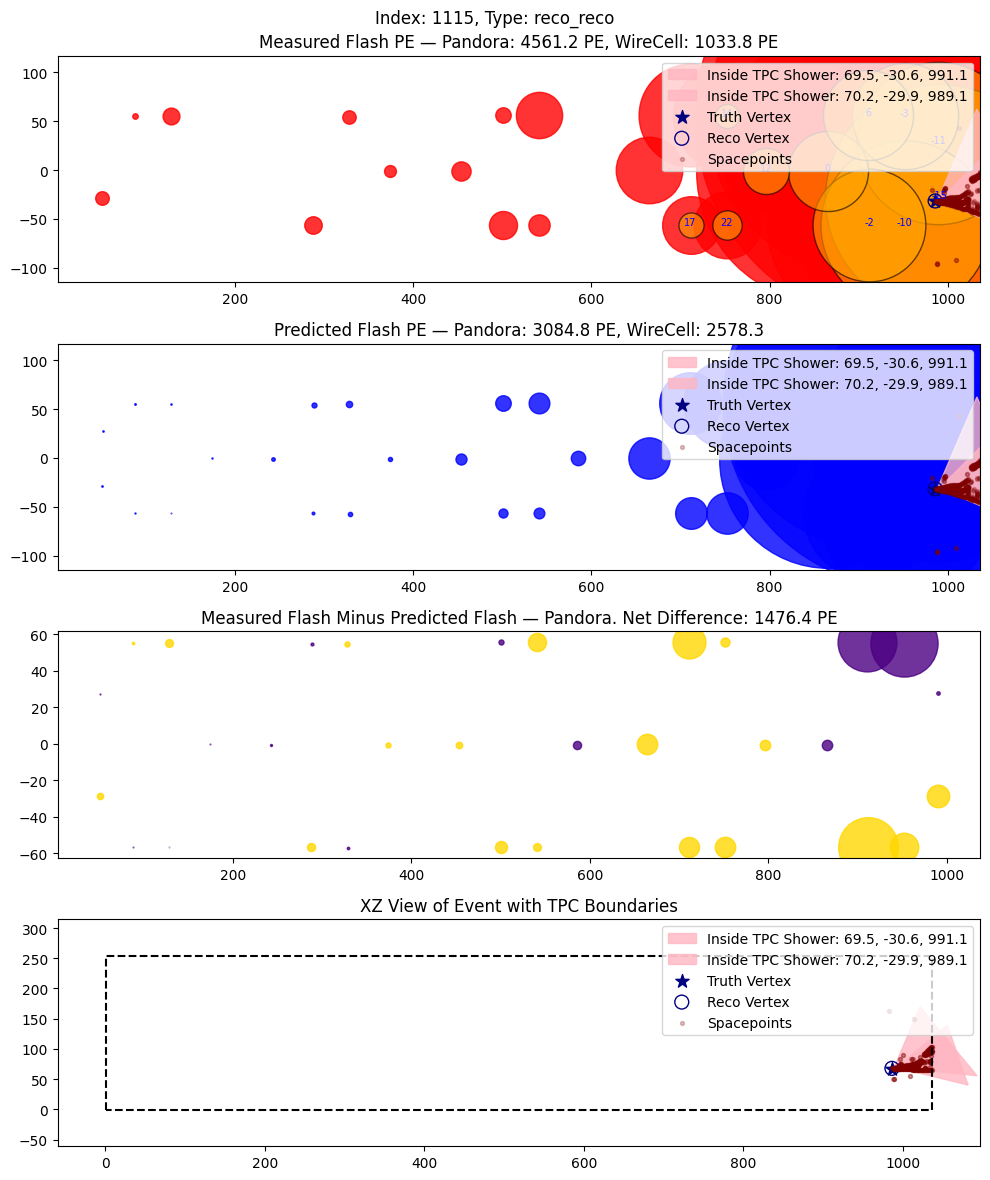

[(np.float32(4149.5005), np.int32(0), np.float32(78.00405), np.False_), (np.float32(4157.7554), np.int32(1), np.float32(55.97242), np.False_), (np.float32(4141.3823), np.int32(2), np.float32(182.2631), np.True_), (np.float32(4152.049), np.int32(3), np.float32(44.32097), np.False_), (np.float32(4137.296), np.int32(4), np.float32(359.3034), np.True_), (np.float32(4142.5386), np.int32(5), np.float32(197.17642), np.True_), (np.float32(4150.3335), np.int32(6), np.float32(87.843056), np.False_), (np.float32(4166.1055), np.int32(7), np.float32(3.9771051), np.False_), (np.float32(4163.811), np.int32(9), np.float32(14.639988), np.False_), (np.float32(4173.7417), np.int32(11), np.float32(5.921629), np.False_), (np.float32(4168.984), np.int32(12), np.float32(4.334474), np.False_)]


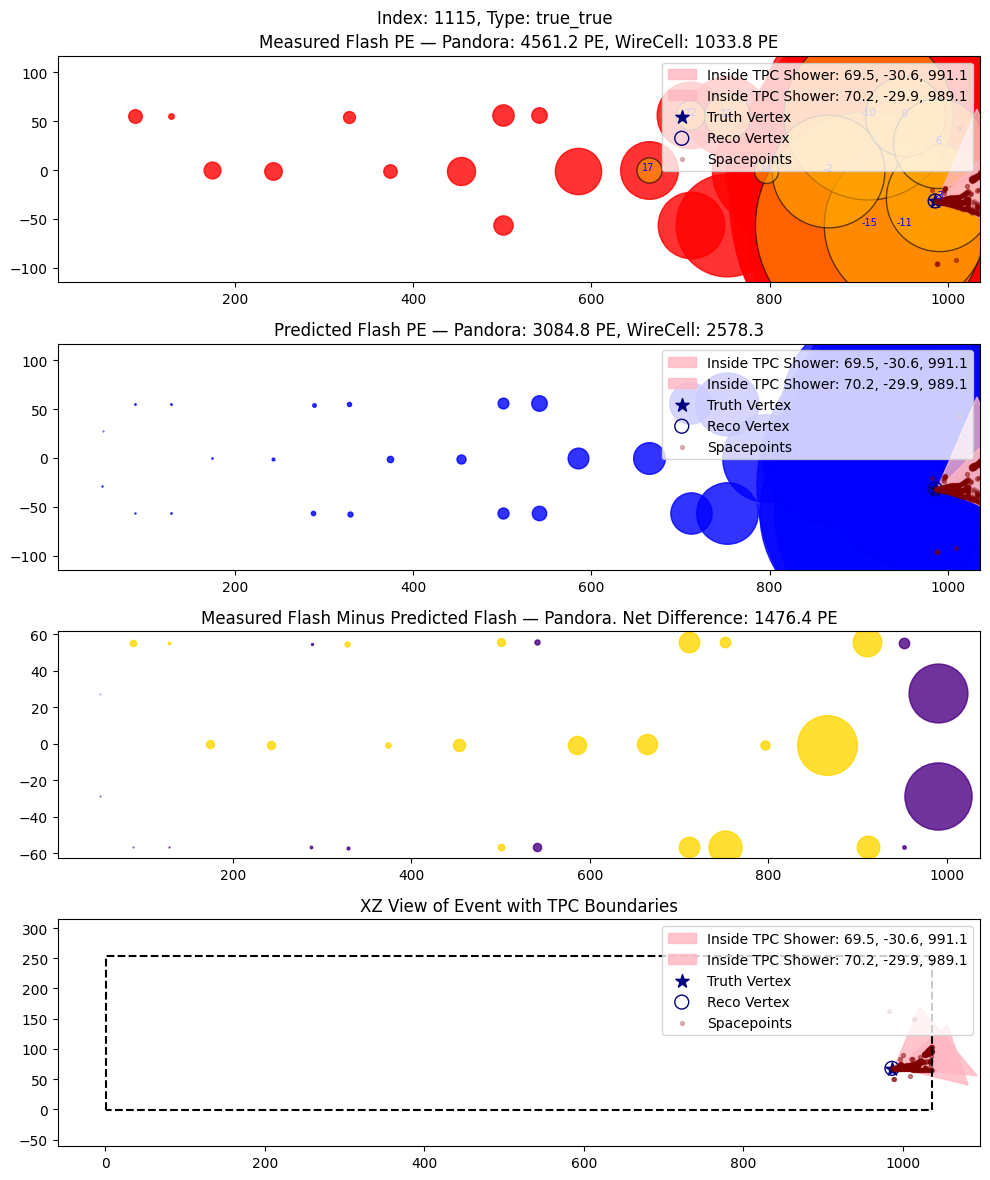

[(np.float32(4149.5005), np.int32(0), np.float32(78.00405), np.False_), (np.float32(4157.7554), np.int32(1), np.float32(55.97242), np.False_), (np.float32(4141.3823), np.int32(2), np.float32(182.2631), np.True_), (np.float32(4152.049), np.int32(3), np.float32(44.32097), np.False_), (np.float32(4137.296), np.int32(4), np.float32(359.3034), np.True_), (np.float32(4142.5386), np.int32(5), np.float32(197.17642), np.True_), (np.float32(4150.3335), np.int32(6), np.float32(87.843056), np.False_), (np.float32(4166.1055), np.int32(7), np.float32(3.9771051), np.False_), (np.float32(4163.811), np.int32(9), np.float32(14.639988), np.False_), (np.float32(4173.7417), np.int32(11), np.float32(5.921629), np.False_), (np.float32(4168.984), np.int32(12), np.float32(4.334474), np.False_)]


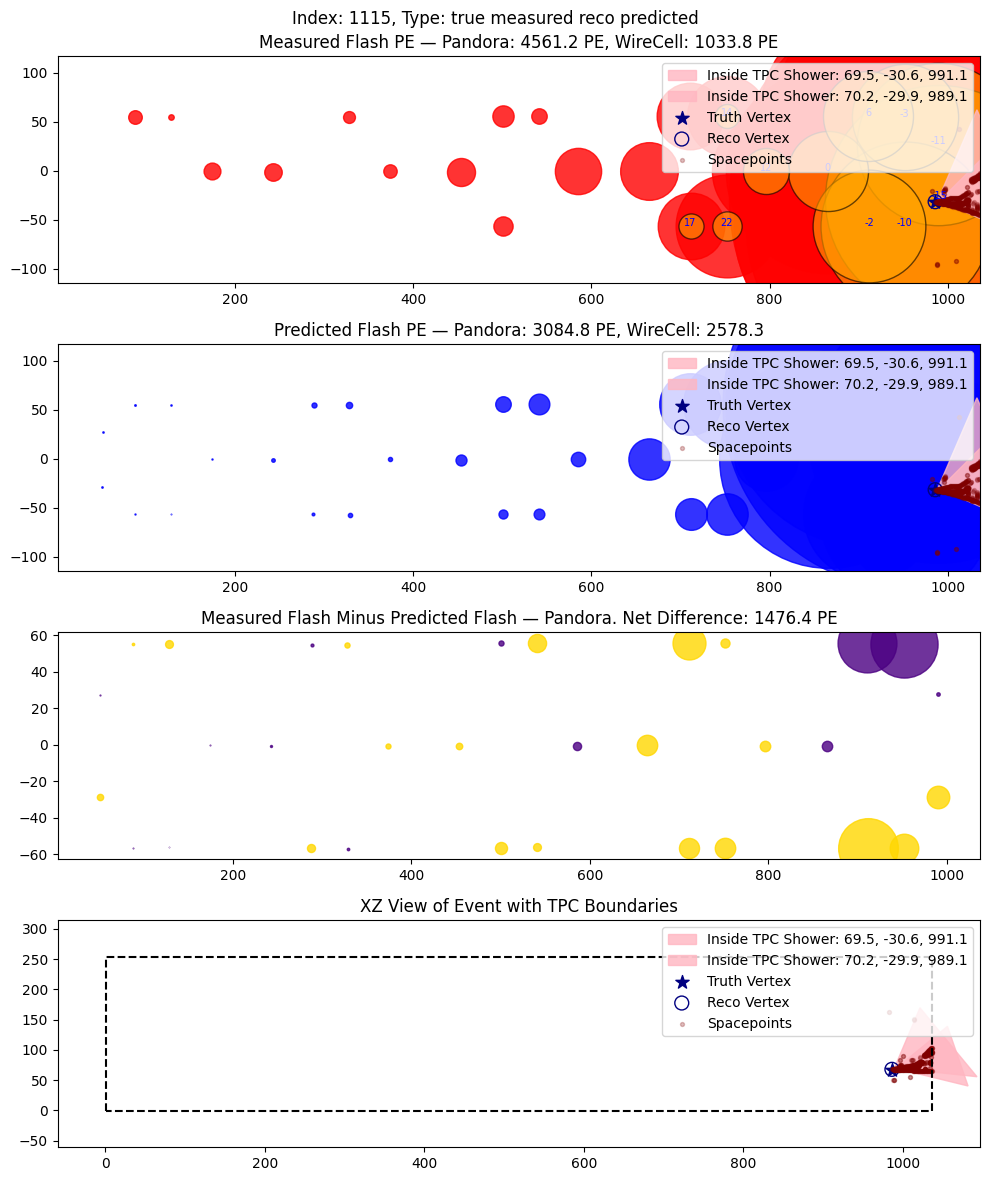

[(np.float32(4149.5005), np.int32(0), np.float32(78.00405), np.False_), (np.float32(4157.7554), np.int32(1), np.float32(55.97242), np.False_), (np.float32(4141.3823), np.int32(2), np.float32(182.2631), np.True_), (np.float32(4152.049), np.int32(3), np.float32(44.32097), np.False_), (np.float32(4137.296), np.int32(4), np.float32(359.3034), np.True_), (np.float32(4142.5386), np.int32(5), np.float32(197.17642), np.True_), (np.float32(4150.3335), np.int32(6), np.float32(87.843056), np.False_), (np.float32(4166.1055), np.int32(7), np.float32(3.9771051), np.False_), (np.float32(4163.811), np.int32(9), np.float32(14.639988), np.False_), (np.float32(4173.7417), np.int32(11), np.float32(5.921629), np.False_), (np.float32(4168.984), np.int32(12), np.float32(4.334474), np.False_)]


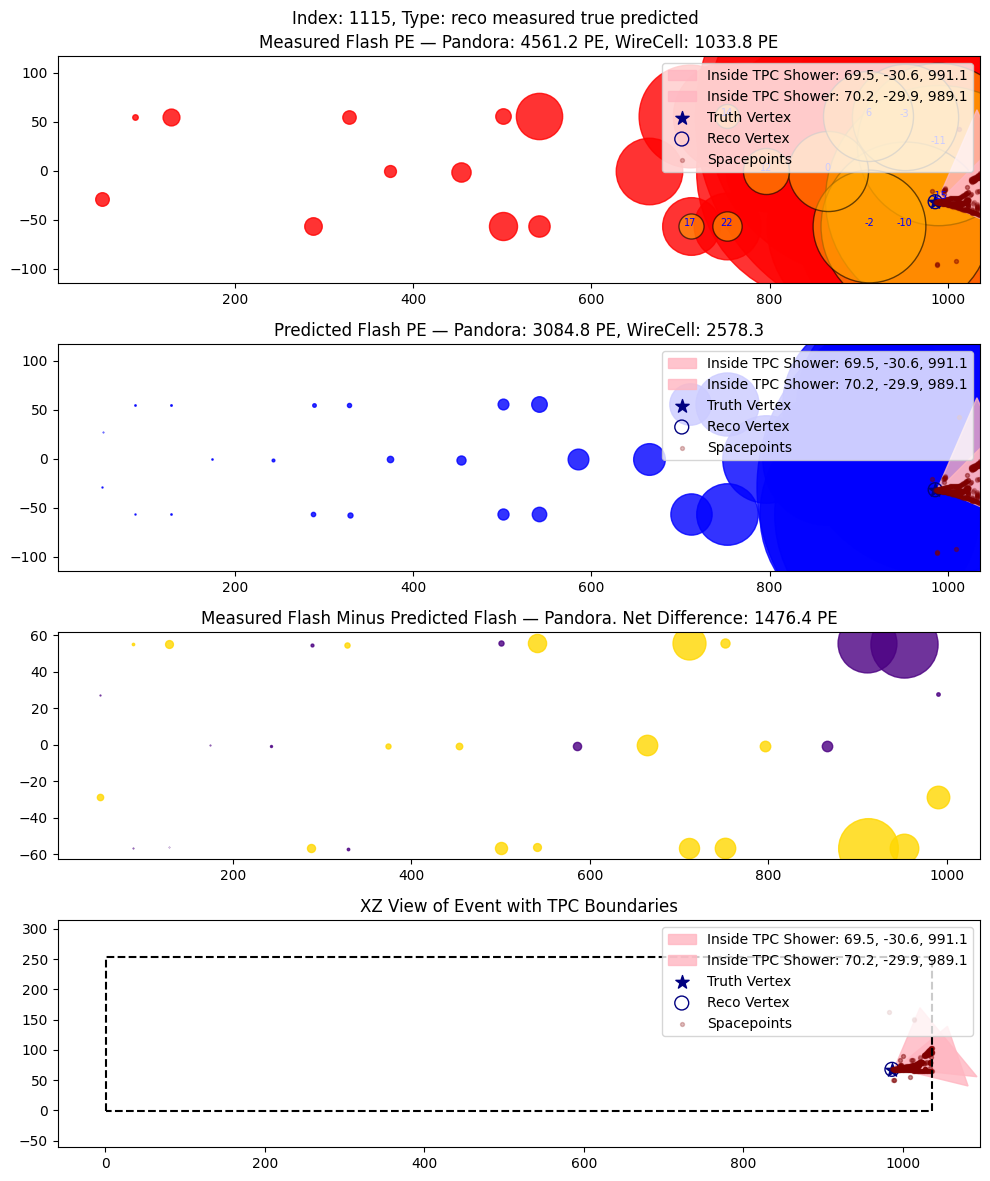

In [34]:
event = 1115
reco_reco(event, "reco_reco")
true_true(event, "true_true")
true_reco(event, "true measured reco predicted")
reco_true(event, "reco measured true predicted")